<a href="https://colab.research.google.com/github/michaelraykuster-spec/Werkplaats-2-opdracht-Groep-3/blob/main/Werkplaats_2_opdracht_Groep_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [358]:
!pip install python-pptx --quiet

In [359]:
!pip install fredapi -q

#Boilerplate

Dit is boiletplate code om diverse functies in te laden

In [360]:
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import nltk
import yfinance as yf
import scipy.optimize as sco
import scipy.interpolate as sci
import base64
import requests
import json

from fredapi import Fred
from google.colab import userdata
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from textblob import TextBlob
from scipy import stats
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import date
from transformers import pipeline
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tabulate import tabulate
from matplotlib.ticker import FuncFormatter

#Clear output
from google.colab import output
output.clear()

In [361]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)

#Lesweek 1

We gaan een portfolio maken via Yahoo Finance en we gaan macro-economische data inlezen bij de FED in St. Louis: https://fred.stlouisfed.org/categories

Hier wordt de begin, einddatum en de cijfers van de diverse items in de portfolio ingeladen.

In [362]:
fred = Fred(api_key=userdata.get('FRED_TOKEN'))

start = dt.datetime(2015,12,25)
end = dt.datetime(2026,5,25)

def get_fred(code):
    s = fred.get_series(code, observation_start=start, observation_end=end)
    return s.to_frame(name=code)

#Aandelen, Crypto's en obligaties
CBOE_interest = yf.download('^TNX', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
yield5 = yf.download('^FVX', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
broadcom = yf.download('AVGO', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
bitcoin = yf.download('BTC-USD', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
qualcomm = yf.download('QCOM', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
stellan = yf.download('STLA', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
asml = yf.download('ASML', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
netflix = yf.download('NFLX', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
apple = yf.download('AAPL', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)
shell = yf.download('SHEL', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None)

#Grondstoffen
graan = get_fred('PWHEAMTUSDM') #graan
hout = get_fred('WPU08') #hout
koffie = get_fred('WPU026301') #koffiebonen
gas = get_fred('GASREGW') #gas (US Regular All Formulations Gas Price)
goud = yf.download('GC=F', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None) #goud future
olie = yf.download('CL=F', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None) #olie
koper = get_fred('PCOPPUSDM') #koperprijs
staal = get_fred('WPU101707') #staal (Producer Price Index by Commodity: Metals and Metal Products: Cold Rolled Steel Sheet and Strip )
zilver = yf.download('SI=F', start=start, end=end, auto_adjust=True, progress=False).tz_localize(None) #zilver future
katoen = get_fred('PCOTTINDUSDM') #katoen

#Economische indicatoren
inflatie_10y = get_fred('T10YIE') #10-Year Breakeven Inflation Rate
fed_funds = get_fred('FEDFUNDS') #Federal Funds Effective Rate, het rente percentage op leningen in Amerika
werkloosheid = get_fred('UNRATE') #het werkloosheidspercentage in Amerika
bbp = get_fred('GDP') #Het BBP in Amerika
persoonlijk_inkomen = get_fred('PI') #Persoonlijk inkomen in Amerika

output.clear()

Dit is de kolommen juiste namen geven

In [363]:
def select_close(df, naam):
    df = df[["Close"]].copy()
    df.columns = [naam]  # force single-level
    return df

def rename_fred(df, naam):
    df.columns = [naam]
    return df

samengevoegd = pd.concat([

    # Yahoo (Close)
    select_close(CBOE_interest, "Close_CBOE_interest"),
    select_close(yield5, "Close_5Y_Yield"),
    select_close(broadcom, "Close_Broadcom"),
    select_close(bitcoin, "Close_Bitcoin"),
    select_close(qualcomm, "Close_Qualcomm"),
    select_close(stellan, "Close_Stellantis"),
    select_close(asml, "Close_ASML"),
    select_close(netflix, "Close_Netflix"),
    select_close(apple, "Close_Apple"),
    select_close(shell, "Close_Shell"),
    select_close(goud, "Close_Gold"),
    select_close(olie, "Close_Oil"),
    select_close(zilver, "Close_Silver"),

    # FRED (direct rename)
    rename_fred(graan, "Grain"),
    rename_fred(hout, "Wood"),
    rename_fred(koffie, "Coffee"),
    rename_fred(gas, "Gasoline"),
    rename_fred(koper, "Copper"),
    rename_fred(staal, "Steel"),
    rename_fred(katoen, "Cotton"),

    #Economische indicatoren
    rename_fred(inflatie_10y, "Inflatie_10y"),
    rename_fred(fed_funds, "Fed_Funds"),
    rename_fred(werkloosheid, "Unemployment"),
    rename_fred(bbp, "GDP"),
    rename_fred(persoonlijk_inkomen, "Income")

], axis=1)

# Resultaat
samengevoegd.head()

,Close_CBOE_interest,Close_5Y_Yield,Close_Broadcom,Close_Bitcoin,Close_Qualcomm,Close_Stellantis,Close_ASML,Close_Netflix,Close_Apple,Close_Shell,Close_Gold,Close_Oil,Close_Silver,Grain,Wood,Coffee,Gasoline,Copper,Steel,Cotton,Inflatie_10y,Fed_Funds,Unemployment,GDP,Income
2015-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18435.137,NaN
2015-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.893455,219.5,202.4,NaN,4638.833333,176.2,70.388095,NaN,0.24,5.0,NaN,15668.4
2015-12-25,NaN,NaN,NaN,455.653015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-26,NaN,NaN,NaN,417.273987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-27,NaN,NaN,NaN,422.822998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##Dubbele rijen vinden

Dit is code om dubbele invoeren te vinden, er wordt gezocht in de initiele tabel, waar geen dubbele invoeren worden gevonden, dit wordt gedaan omdat als je alleen kijkt naar de gefilterde data, dan wordt de kans grote op false positives.

In [364]:
aantal_dubbele_rijen = samengevoegd.duplicated().sum()
print(f"Aantal dubbele rijen: {aantal_dubbele_rijen}")

# Om de dubbele rijen zelf te zien:
dubbele_rijen = samengevoegd[samengevoegd.duplicated(keep=False)]
# 'keep=False' markeert alle voorkomens van de dubbele rijen als True, niet alleen de duplicaten na de eerste
display(dubbele_rijen.sort_values(by=list(dubbele_rijen.columns)))

Aantal dubbele rijen: 0


,Close_CBOE_interest,Close_5Y_Yield,Close_Broadcom,Close_Bitcoin,Close_Qualcomm,Close_Stellantis,Close_ASML,Close_Netflix,Close_Apple,Close_Shell,Close_Gold,Close_Oil,Close_Silver,Grain,Wood,Coffee,Gasoline,Copper,Steel,Cotton,Inflatie_10y,Fed_Funds,Unemployment,GDP,Income


##Forward fill

NaN's eruithalen met forwardfill en de eerste regel laten vallen

In [365]:
samengevoegd_fil = samengevoegd.ffill()
samengevoegd_fil.head(10)

,Close_CBOE_interest,Close_5Y_Yield,Close_Broadcom,Close_Bitcoin,Close_Qualcomm,Close_Stellantis,Close_ASML,Close_Netflix,Close_Apple,Close_Shell,Close_Gold,Close_Oil,Close_Silver,Grain,Wood,Coffee,Gasoline,Copper,Steel,Cotton,Inflatie_10y,Fed_Funds,Unemployment,GDP,Income
2015-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18435.137,NaN
2015-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.893455,219.5,202.4,NaN,4638.833333,176.2,70.388095,NaN,0.24,5.0,18435.137,15668.4
2015-12-25,NaN,NaN,NaN,455.653015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.893455,219.5,202.4,NaN,4638.833333,176.2,70.388095,NaN,0.24,5.0,18435.137,15668.4
2015-12-26,NaN,NaN,NaN,417.273987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.893455,219.5,202.4,NaN,4638.833333,176.2,70.388095,NaN,0.24,5.0,18435.137,15668.4
2015-12-27,NaN,NaN,NaN,422.822998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.893455,219.5,202.4,NaN,4638.833333,176.2,70.388095,NaN,0.24,5.0,18435.137,15668.4
2015-12-28,2.225,1.716,11.164363,422.278992,37.168056,4.985761,82.524055,11.711,24.039928,27.360580,1070.500000,36.810001,13.873,163.893455,219.5,202.4,2.034,4638.833333,176.2,70.388095,1.50,0.24,5.0,18435.137,15668.4
2015-12-29,2.307,1.783,11.285659,432.983002,38.142609,5.010168,82.839470,11.912,24.472021,27.754599,1077.500000,37.869999,13.917,163.893455,219.5,202.4,2.034,4638.833333,176.2,70.388095,1.53,0.24,5.0,18435.137,15668.4
2015-12-30,2.303,1.799,11.242175,426.619995,37.790272,4.933464,82.316803,11.671,24.152456,27.456095,1060.099976,36.599998,13.814,163.893455,219.5,202.4,2.034,4638.833333,176.2,70.388095,1.54,0.24,5.0,18435.137,15668.4
2015-12-31,2.269,1.758,11.072821,430.566986,37.475426,4.877677,80.000671,11.438,23.688847,27.336702,1060.300049,37.040001,13.775,163.893455,219.5,202.4,2.034,4638.833333,176.2,70.388095,1.54,0.24,5.0,18435.137,15668.4
2016-01-01,2.269,1.758,11.072821,434.334015,37.475426,4.877677,80.000671,11.438,23.688847,27.336702,1060.300049,37.040001,13.775,164.611627,219.8,201.9,2.034,4471.787500,173.9,68.750000,1.54,0.34,4.8,18525.933,15695.5


##heatmap

gemaakt om de onderzoeksvragen te bepalen

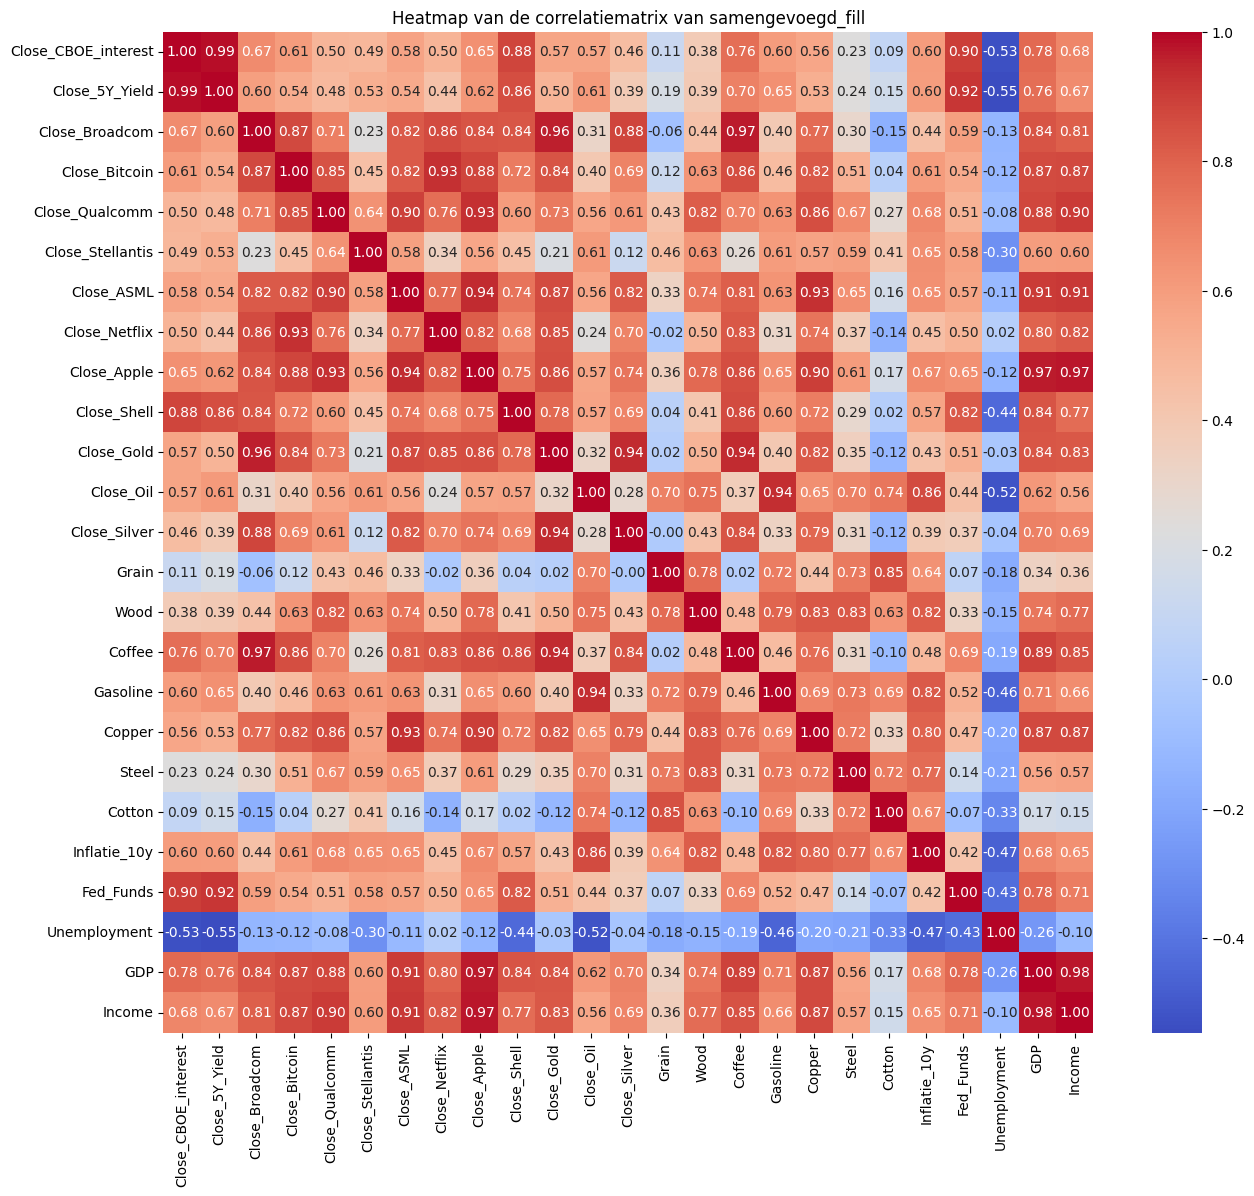

In [366]:
plt.figure(figsize=(15, 13))
sns.heatmap(samengevoegd_fil.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap van de correlatiematrix van samengevoegd_fill')
plt.show()

Alleen de data geselecteerd die nodig is voor de onderzoeksvragen

In [367]:
data = samengevoegd_fil.loc[:, ["GDP", "Income", "Coffee", "Gasoline", "Copper", "Close_Broadcom", "Close_Oil", "Close_Gold", "Close_ASML", "Close_Shell", "Close_Apple"]]
data = data.dropna()
data.head()


,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
2015-12-28,18435.137,15668.4,202.4,2.034,4638.833333,11.164363,36.810001,1070.500000,82.524055,27.360580,24.039928
2015-12-29,18435.137,15668.4,202.4,2.034,4638.833333,11.285659,37.869999,1077.500000,82.839470,27.754599,24.472021
2015-12-30,18435.137,15668.4,202.4,2.034,4638.833333,11.242175,36.599998,1060.099976,82.316803,27.456095,24.152456
2015-12-31,18435.137,15668.4,202.4,2.034,4638.833333,11.072821,37.040001,1060.300049,80.000671,27.336702,23.688847
2016-01-01,18525.933,15695.5,201.9,2.034,4471.787500,11.072821,37.040001,1060.300049,80.000671,27.336702,23.688847


##Dagrendement berekenen

Hier worden de koersen omgezet worden naar dagrendementen

In [368]:
dag_rendement = data.pct_change()
dag_rendement = dag_rendement.dropna()
dag_rendement

,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
2015-12-29,0.000000,0.00000,0.00000,0.000000,0.00000,0.010865,0.028796,0.006539,0.003822,0.014401,0.017974
2015-12-30,0.000000,0.00000,0.00000,0.000000,0.00000,-0.003853,-0.033536,-0.016149,-0.006309,-0.010755,-0.013058
2015-12-31,0.000000,0.00000,0.00000,0.000000,0.00000,-0.015064,0.012022,0.000189,-0.028137,-0.004348,-0.019195
2016-01-01,0.004925,0.00173,-0.00247,0.000000,-0.03601,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-01-02,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
2026-05-21,0.000000,0.00000,0.00000,0.000000,0.00000,-0.007636,-0.019438,0.001876,0.027011,0.002422,0.009065
2026-05-22,0.000000,0.00000,0.00000,0.000000,0.00000,-0.001037,0.002595,-0.004141,0.025691,-0.005094,0.012558
2026-05-23,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-05-24,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#Lesweek 2


##.Describe
We gaan alle statistische maatstaven van de 3 portfolio's berekenen en uitleggen

In [369]:
dag_rendement.describe()

,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
count,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000
mean,0.000147,0.000152,0.000160,0.000236,0.000297,0.001158,-0.000432,0.000417,0.000985,0.000426,0.000786
std,0.002534,0.005005,0.003121,0.007722,0.008450,0.020383,0.058981,0.008637,0.019963,0.015790,0.015094
min,-0.082430,-0.128901,-0.019608,-0.056940,-0.167933,-0.199129,-3.059661,-0.113662,-0.173492,-0.171722,-0.128647
25%,0.000000,0.000000,0.000000,0.000000,0.000000,-0.004287,-0.004838,-0.001721,-0.004605,-0.003281,-0.002897
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.007013,0.008184,0.003285,0.007669,0.005239,0.005491
max,0.087490,0.207846,0.099238,0.161526,0.152110,0.244326,0.376623,0.060833,0.154341,0.196795,0.153289


Hier laten we de 2 laagste waardes van Olie vallen want dit zijn de meest extreme waardes in de dataset

In [370]:
lowest_oil_values = dag_rendement['Close_Oil'].nsmallest(2)
print("Lowest oil values:\n", lowest_oil_values)

# Drop the rows corresponding to these lowest values from dag_rendement
dag_rendement = dag_rendement.drop(lowest_oil_values.index)
print("\ndag_rendement after dropping the rows (first 5 rows):\n", dag_rendement.head())

Lowest oil values:
 2020-04-20   -3.059661
2020-04-21   -1.266011
Name: Close_Oil, dtype: float64

dag_rendement after dropping the rows (first 5 rows):
                  GDP   Income   Coffee  Gasoline   Copper  Close_Broadcom  \
2015-12-29  0.000000  0.00000  0.00000       0.0  0.00000        0.010865   
2015-12-30  0.000000  0.00000  0.00000       0.0  0.00000       -0.003853   
2015-12-31  0.000000  0.00000  0.00000       0.0  0.00000       -0.015064   
2016-01-01  0.004925  0.00173 -0.00247       0.0 -0.03601        0.000000   
2016-01-02  0.000000  0.00000  0.00000       0.0  0.00000        0.000000   

            Close_Oil  Close_Gold  Close_ASML  Close_Shell  Close_Apple  
2015-12-29   0.028796    0.006539    0.003822     0.014401     0.017974  
2015-12-30  -0.033536   -0.016149   -0.006309    -0.010755    -0.013058  
2015-12-31   0.012022    0.000189   -0.028137    -0.004348    -0.019195  
2016-01-01   0.000000    0.000000    0.000000     0.000000     0.000000  
2016-01-02   

In [371]:
dag_rendement.describe()

,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
count,3799.000000,3799.000000,3799.000000,3799.000000,3799.000000,3799.000000,3799.000000,3799.000000,3799.000000,3799.000000,3799.000000
mean,0.000147,0.000152,0.000160,0.000242,0.000297,0.001177,0.000706,0.000418,0.000999,0.000445,0.000800
std,0.002534,0.005006,0.003122,0.007715,0.008452,0.020371,0.024359,0.008636,0.019958,0.015765,0.015085
min,-0.082430,-0.128901,-0.019608,-0.056940,-0.167933,-0.199129,-0.245882,-0.113662,-0.173492,-0.171722,-0.128647
25%,0.000000,0.000000,0.000000,0.000000,0.000000,-0.004269,-0.004748,-0.001716,-0.004574,-0.003272,-0.002889
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.007027,0.008185,0.003284,0.007673,0.005244,0.005492
max,0.087490,0.207846,0.099238,0.161526,0.152110,0.244326,0.376623,0.060833,0.154341,0.196795,0.153289


De waardes van GDP, Income, Copper en Coffee zijn niet goed uit te leggen met deze methode door het gebruik van Forward fill, hierdoor zijn bijna alle veranderingen 0

##Mediaan en Modus

In [372]:
medianen_alle_kolommen = data.median(numeric_only=True)
print("\nMedianen voor alle numerieke kolommen:")
print(medianen_alle_kolommen)


Medianen voor alle numerieke kolommen:
GDP               22680.693000
Income            21008.400000
Coffee              198.578000
Gasoline              2.865000
Copper             7772.238095
Close_Broadcom       41.274307
Close_Oil            63.580002
Close_Gold         1775.750000
Close_ASML          458.803589
Close_Shell          45.552305
Close_Apple         124.232109
dtype: float64


De berekingen van de mediaan is op basis van de reële koers gedaan.



In [373]:
modi_alle_kolommen = dag_rendement.mode(numeric_only=True)
print("\nModi voor alle numerieke kolommen:")
display(modi_alle_kolommen)


Modi voor alle numerieke kolommen:


,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


De modi zijn berekend op basis van het dagrendement, door de Forward fill zijn alle waardes nul.

##Boxplot

<Axes: >

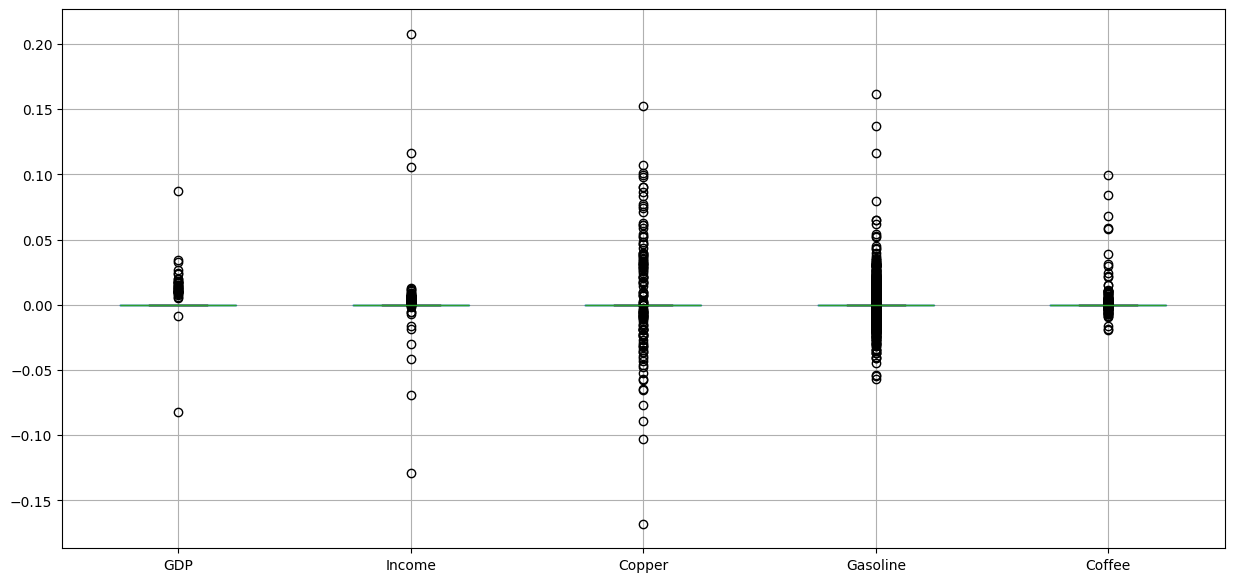

In [374]:
dag_rendement.boxplot(column=["GDP", "Income","Copper","Gasoline","Coffee"], figsize=(15, 7))

Deze boxplots zijn berekend door: <br> min = Q1 - ((Q3 - Q1) * 1,5)
<br>max = Q3 + ((Q3 - Q1) * 1,5)

Alles is tussen de 25% en 75% op 0, dit komt door Forward fill. Income heeft de grootste uitschieters. Copper is het meest volatiel, dit is te zien aan de constante uitwijkingen.



<Axes: >

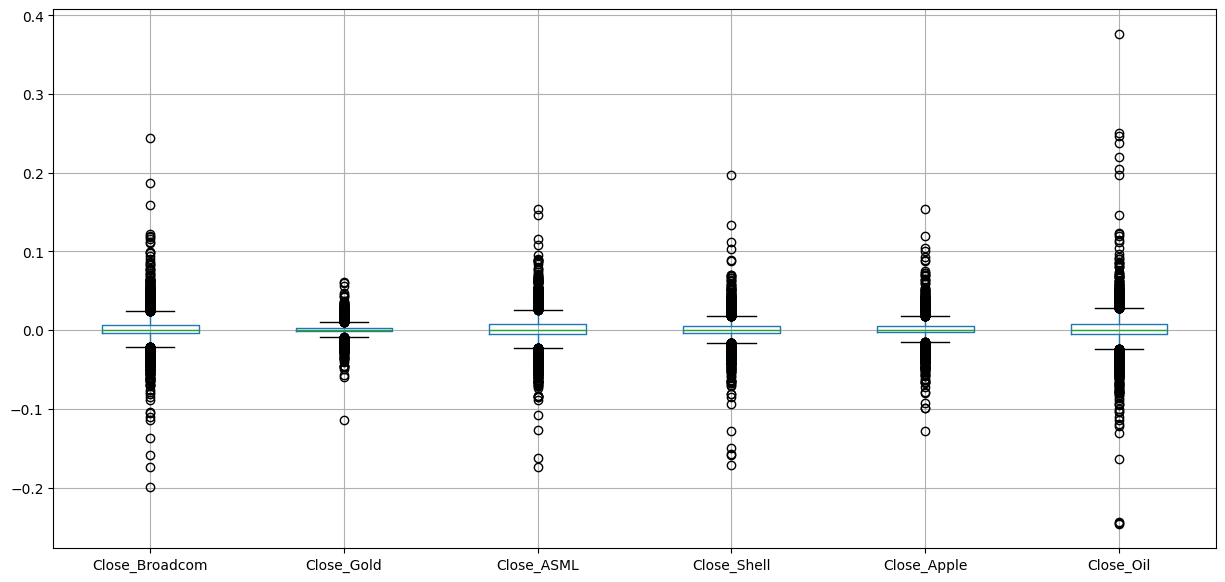

In [375]:
dag_rendement.boxplot(column=["Close_Broadcom","Close_Gold","Close_ASML","Close_Shell","Close_Apple","Close_Oil"], figsize=(15, 7))

De 2 laagste waardes van Olie waren laten vallen omdat het de boxplot onleesbaar maakte.

Alle assets hebben een mediaan rond nul (normaal voor dagrendementen), maar verschillen sterk in volatiliteit. Oil en Broadcom hebben de grootste spreiding, Gold is het stabielst.

##Histogram

Een histogram is een grafische weergave in data-analyse die de frequentieverdeling van numerieke gegevens toont door middel van staven.

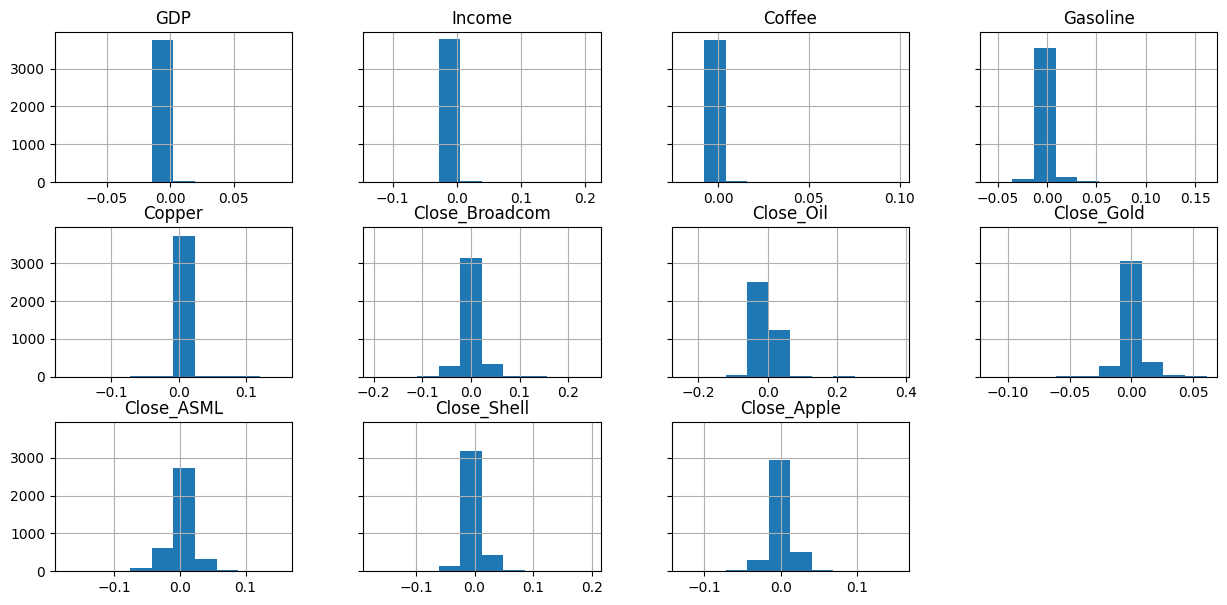

In [376]:
dag_rendement.hist(layout=(3, 4), figsize=(15, 7), sharey=True)
plt.show()

Alle verdelingen zijn smal en gecentreerd rond nul, met dikkere staarten dan een normale verdeling. Close_Oil en Close_Broadcom zijn het meest volatiel. Close_Gold en de macro-economische indicatoren het meest stabiel.

##Scheefheid

Dit geeft aan of de verdeling symmetrisch, links- of rechtsscheef is.

Als skewness = 0: verdeling is symmetrisch<br>
Als skewness < 0: verdeling is linksscheef, de staarten aan de linkerkant zijn groter / langer dan bij een symmetrische verdeling<br>
Als skewness > 0: verdeling is rechtsscheef, de staarten aan de rechterkant zijn groter / langer dan bij een symmetrische verdeling

In [377]:
dag_rendement.skew()

,0
GDP,4.995106
Income,19.138900
Coffee,20.907488
Gasoline,5.629032
Copper,2.464528
Close_Broadcom,0.440317
Close_Oil,1.250928
Close_Gold,-0.676047
Close_ASML,-0.099199
Close_Shell,-0.452851


Coffee en Income zijn het scheefst. Alle verdelingen zijn asymmetrisch.

##Kurtosis
Dit geeft aan of de verdeling 'spits' (met veel uitschieters) of 'vlak' (met weinig uitschieters) is.
<p>
Als kurtosis = 0: verdeling is symmetrisch<br>
Als kurtosis =< 3: verdeling heeft weinig uitschieters<br>
Als kurtosis > 3: verdeling heeft veel uitschieters<br>

In [378]:
dag_rendement.kurtosis()

,0
GDP,698.436535
Income,1034.103477
Coffee,540.102811
Gasoline,104.713709
Copper,128.579062
Close_Broadcom,17.295411
Close_Oil,37.733438
Close_Gold,14.536812
Close_ASML,7.819123
Close_Shell,24.059140


Doordat de gebruikte data over tien jaar is en een koers, krijg je uitschieters.

##Heatmap van de relevante data

Met deze code kan je de correlatie berekenen en in een matrix hittematrix laten zien.

Als de correlatiecoëfficiënt ligt tussen de -0,3 en 0,3 is er geen sprake van correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,3 -0,6) of (0,3 0,6) is er sprake van zwakke correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,6 -0,9) of (0,6 0,9) is er sprake van matige correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,9 -1) of (0,9 1) is er sprake van sterke correlatie.

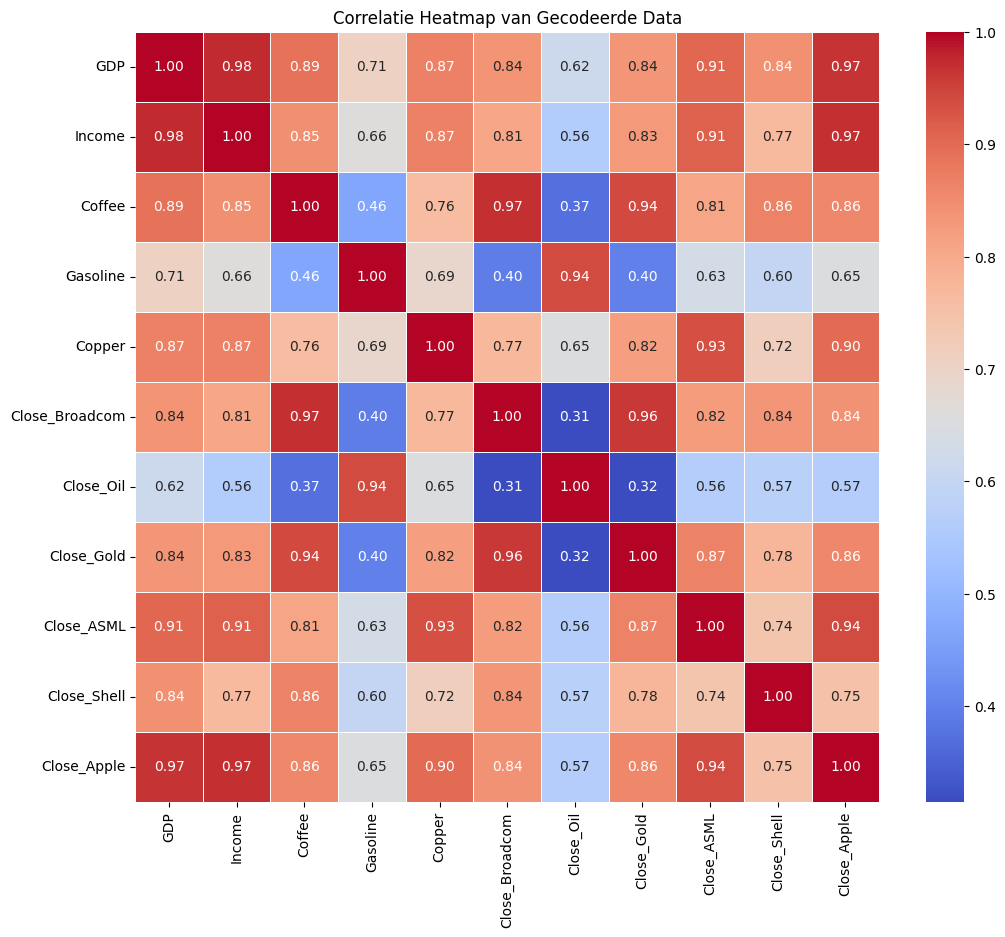

In [379]:
correlation_matrix = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlatie Heatmap van Gecodeerde Data')
plt.show()

Wij hebben gekozen om de rouwe data van de koers te gebruiken in plaats van de data die berekend is bij het dagrendement, dit is besloten omdat de vele 0 waardes dit door Forward Fill geintroduceerd zijn de heatmap van dagrendement onbetrouwbaar maakt.<p>
In deze heatmap is dezelfde informatie gezien als in de eerdere heatmap maar het is hier beter af te lezen, er zijn een heleboel correlaties sinds dit is ook de reden voor het kiezen van deze variabelen.

## Bubble Charts

Deze bubble charts tonen de relatie tussen drie variabelen, waarbij de grootte van de cirkel een extra dimensie vertegenwoordigt. De schaal van de groottevariabele is aangepast voor betere visualisatie.

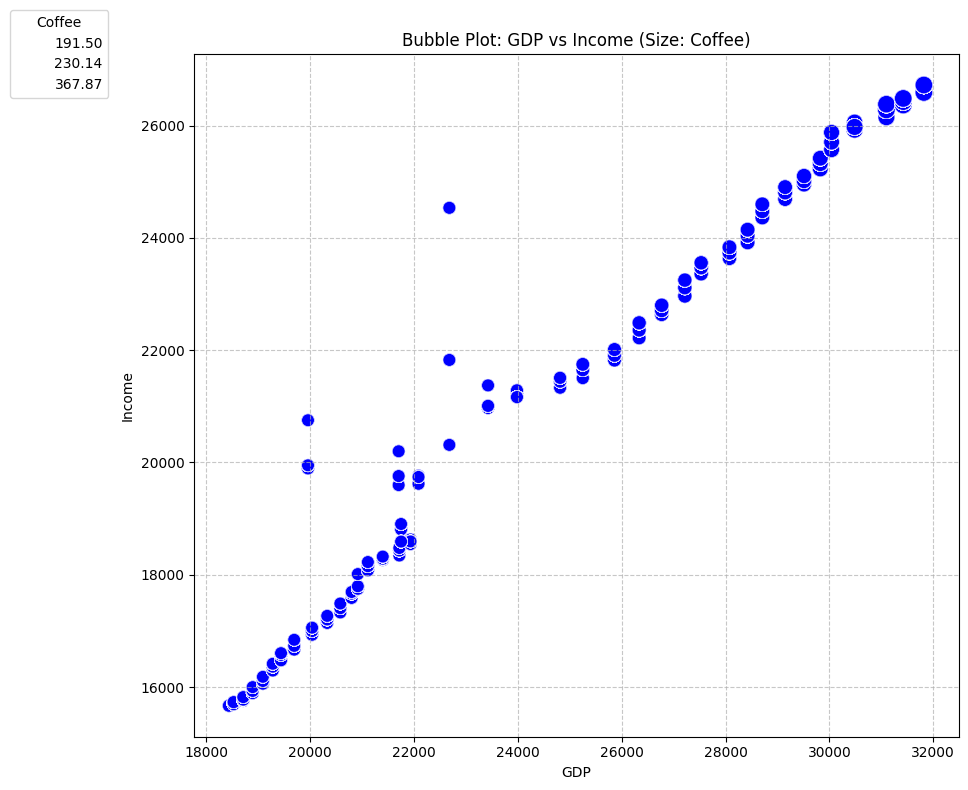

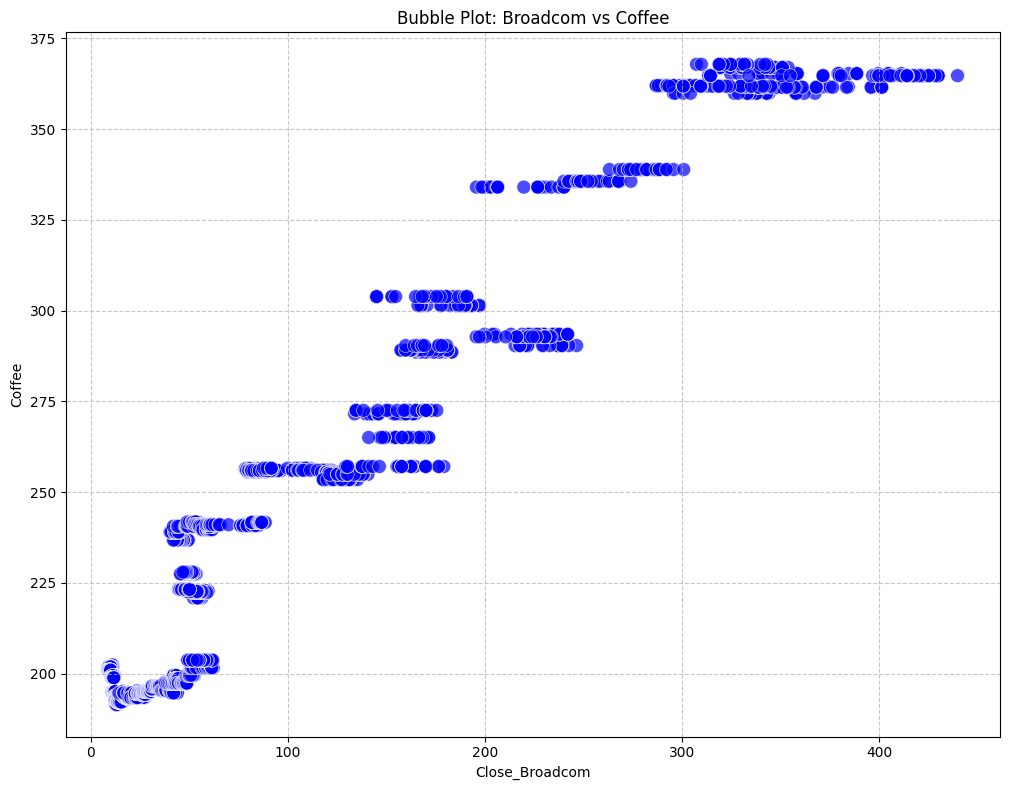

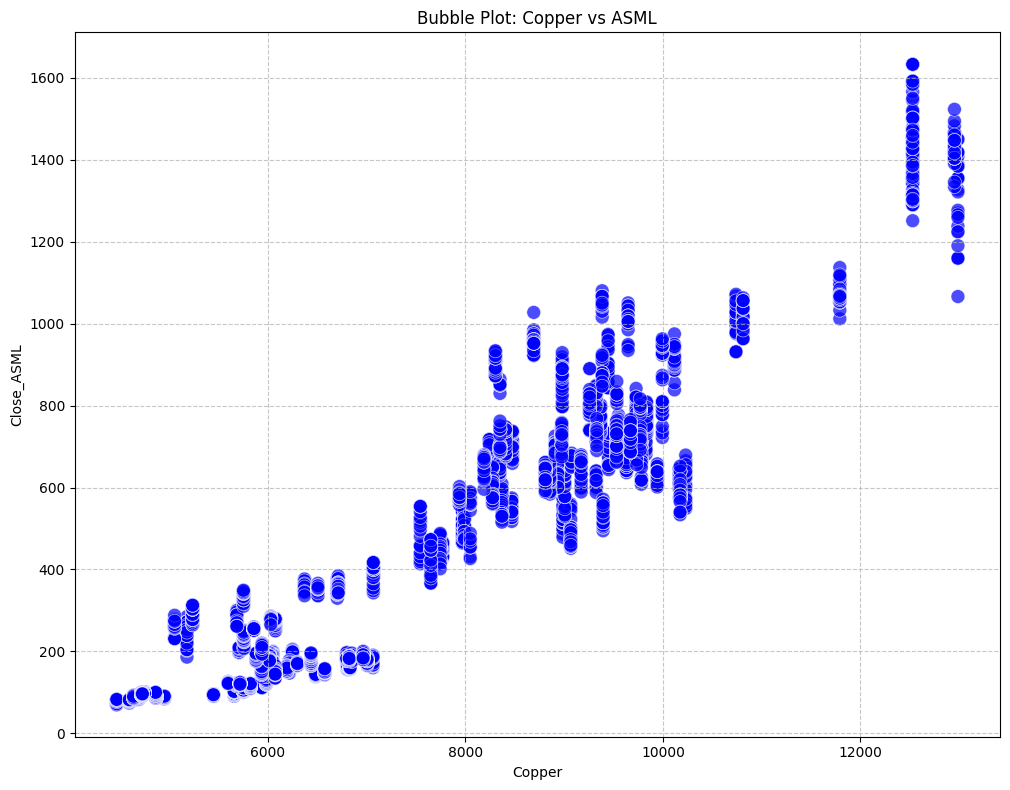

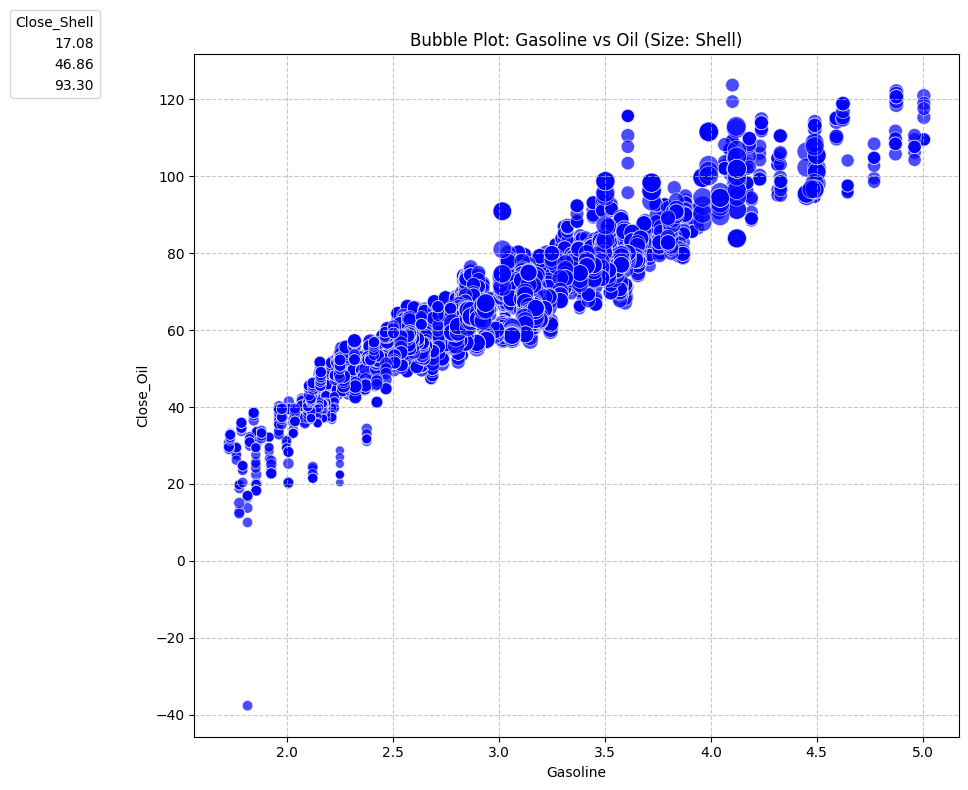

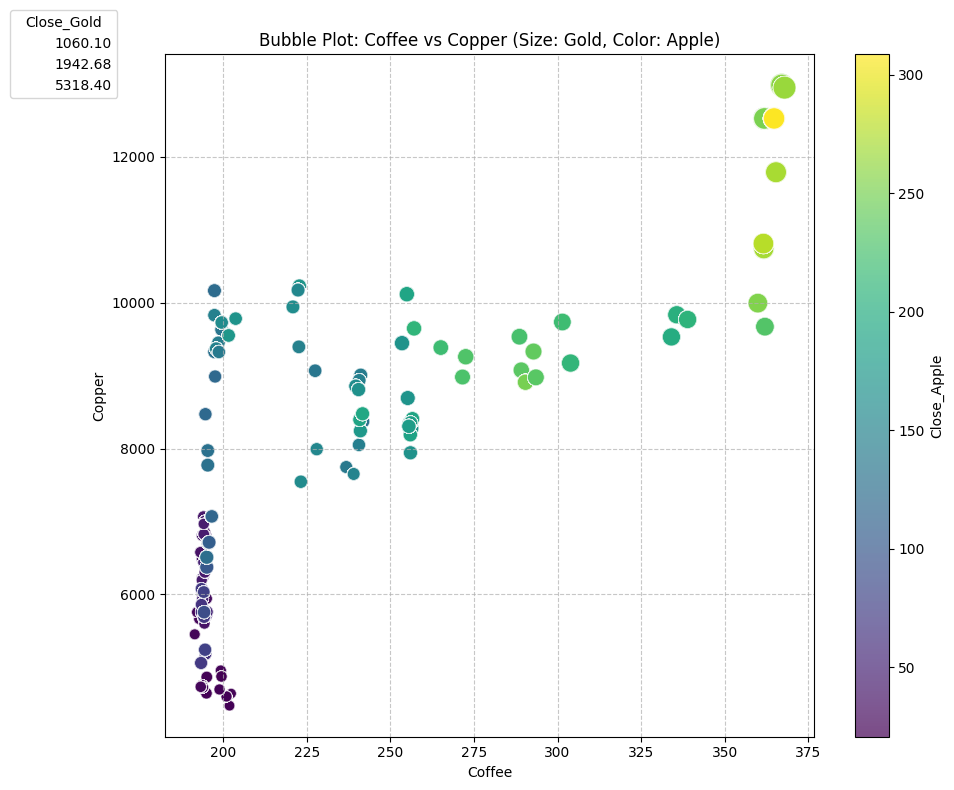

In [380]:
def create_bubble_plot(df, x_col, y_col, size_col=None, color_col=None, title=''):
    plt.figure(figsize=(12, 8))

    # Handle size column
    if size_col and size_col in df.columns:
        sizes = df[size_col] / df[size_col].mean() * 100  # Adjust scaling factor as needed
        size_args = {'s': sizes}
    else:
        sizes = pd.Series([100] * len(df)) # Default fixed size
        size_args = {'s': sizes}

    # Handle color column
    if color_col and color_col in df.columns:
        color_args = {'c': df[color_col], 'cmap': 'viridis'}
    else:
        color_args = {'c': 'blue'}

    scatter = plt.scatter(df[x_col], df[y_col], **size_args, **color_args, alpha=0.7, edgecolors='w', linewidth=0.5)

    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Create a legend for sizes if size_col is provided
    if size_col and size_col in df.columns:
        handles, labels = scatter.legend_elements(prop="sizes", alpha=0., num=[sizes.min(), sizes.mean(), sizes.max()])
        plt.legend(handles, [f'{s_val:.2f}' for s_val in [df[size_col].min(), df[size_col].mean(), df[size_col].max()]], title=size_col, loc='center left', bbox_to_anchor=(-0.25, 1))

    # Add a colorbar for the color variable if color_col is provided
    if color_col and color_col in df.columns:
        cbar = plt.colorbar(scatter, ax=plt.gca(), orientation='vertical')
        cbar.set_label(color_col)

    plt.tight_layout(rect=[0.15, 0, 1, 1])  # Adjust layout to make space for the legend on the left and colorbar on the right
    plt.show()

# Vraag 1: Wat is het verband tussen GDP (x-as), Income (y-as), Coffee (grootte) en Close_Gold (kleur)?
create_bubble_plot(data, 'GDP', 'Income', 'Coffee', None, 'Bubble Plot: GDP vs Income (Size: Coffee)')

# Vraag 2: Wat is het verband van Close_Broadcom (x3) op de Coffee(y1)?
create_bubble_plot(data, 'Close_Broadcom', 'Coffee', None, None, 'Bubble Plot: Broadcom vs Coffee')

# Vraag 3: Hoeveel invloed heeft de Copper (x4) op de koers van Close_ASML (y2)?
create_bubble_plot(data, 'Copper', 'Close_ASML', None, None, 'Bubble Plot: Copper vs ASML')

# Vraag 4: Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?
create_bubble_plot(data, 'Gasoline', 'Close_Oil', 'Close_Shell', None, 'Bubble Plot: Gasoline vs Oil (Size: Shell)')

# Vraag 5: Wat is het verband tussen Coffee (x7), Copper (x4), Close_Gold (x8) en Close_Apple (y4)?
create_bubble_plot(data, 'Coffee', 'Copper', 'Close_Gold', 'Close_Apple', 'Bubble Plot: Coffee vs Copper (Size: Gold, Color: Apple)')

1.	Wat is het verband tussen GDP (x1), Income (Persoonlijk inkomen) (x2) en Coffee (y1)? <br>
Hoe hoger het inkomen en de GDP, des te hoger de koers van Coffee.
<p>

2.	Wat is het verband van Close_Broadcom (x3) op de Coffee(y1)?<br>
Het is niet een stabiel verband maar wel een relatief positief lineaire verband.
<p>

3.	Hoeveel invloed heeft de Copper (x4) op de koers van Close_ASML (y2)?<br>
Het verband is lineaire verdeeld, maar er is in het midden van de grafiek wel een ophoping.
<p>

4.	Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?<br>
Het verband is lineaire verdeeld, maar begint als de koers van Close_Oil hoog is.
 <p>

5.	Wat is het verband tussen Coffee (x7), Copper (x4), Close_Gold (x8) en Close_Apple (y4)?<br>
Hoe hoger de Coffee-koers, hoe groter en geler de bubbles, dit wijst op een positief verband tussen Coffee, Gold én Apple. Copper lijkt minder een verband te hebben.

#Lesweek 3

##Enkelvoudige en meervoudige regressie

Enkelvoudige regressie onderzoekt het verband tussen één verklarende variabele en een uitkomstvariabele, terwijl meervoudige regressie het effect van meerdere verklarende variabelen tegelijk op één uitkomstvariabele onderzoekt.

Er zijn een aantal waarde die belangrijk zijn, namelijk: <br>
**P (P>|t|):** De p-waarde geeft aan of het effect van een variabele statistisch significant is, dus of het verband waarschijnlijk geen toeval is. Meestal geldt: p < 0,05 betekent een significant effect.<br>
**R-kwadraat (R-squared):** R-kwadraat laat zien hoeveel van de variatie in de uitkomstvariabele door het regressiemodel wordt verklaard. Hoe hoger de waarde (tussen 0 en 1), hoe beter het model de data verklaart.<br>
**Coëfficiënt (coef):** De coëfficiënt geeft aan hoe sterk en in welke richting een variabele invloed heeft op de uitkomstvariabele. Een positieve waarde betekent dat de uitkomst stijgt bij een toename van de variabele, een negatieve waarde betekent dat deze daalt.<p>

Als de correlatiecoëfficiënt ligt tussen de -0,3 en 0,3 is er geen sprake van correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,3 -0,6) of (0,3 0,6) is er sprake van zwakke correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,6 -0,9) of (0,6 0,9) is er sprake van matige correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,9 -1) of (0,9 1) is er sprake van sterke correlatie.

###Onderzoeksvraag 1 regressie

Wat is het verband tussen GDP (x1), Income (Persoonlijk inkomen) (x2) en Coffee (y1)?


In [381]:
X = data[["GDP", "Income"]]
y = data[["Coffee"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Coffee   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     7493.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:48:15   Log-Likelihood:                -17390.
No. Observations:                3802   AIC:                         3.479e+04
Df Residuals:                    3799   BIC:                         3.481e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -25.2494      2.279    -11.079      0.0

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.3 en kleiner dan 0.8, dus er is een matige correlatie. <br>
De coefficient geeft hier aan dat als het GDP met een dollar stijgt, de Coffee koers met 0,0160 dollar stijgt. Als het Income met een dollar stijgt dan daalt de Coffee koers met 0,0064 dollar.<p>
Door het verband tussen de onafhankelijke variabelen, die te zien is in de heatmap, is er niet een realistische conclusie te trekken uit de regressie.

###Onderzoeksvraag 2 regressie

Wat is het verband van Close_Broadcom (x3) op de Coffee(y1)?

In [382]:
X = data[["Close_Broadcom"]]
y = data[["Coffee"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Coffee   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                 5.930e+04
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:48:15   Log-Likelihood:                -15088.
No. Observations:                3802   AIC:                         3.018e+04
Df Residuals:                    3800   BIC:                         3.019e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            188.2828      0.270    698.

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.8, dus er is een sterke correlatie.<br>
De coefficient geeft hier aan dat per dollar stijging van Close_Broadcom de Coffee prijs met 0,5205 dollar stijgt.<p>
Er is geen logisch verband te vinden tussen Broadcom en Coffee, dus er is geen conlusie te trekken uit de regressie.

###Onderzoeksvraag 3 regressie

Hoeveel invloed heeft de Copper (x4) op de koers van Close_ASML (y2)?

In [383]:
X = data[["Copper"]]
y = data[["Close_ASML"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:             Close_ASML   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                 2.563e+04
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:48:15   Log-Likelihood:                -23625.
No. Observations:                3802   AIC:                         4.725e+04
Df Residuals:                    3800   BIC:                         4.727e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -726.2756      7.796    -93.160      0.0

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.8, dus er is een sterke correlatie. <br>
De coefficient geeft hier aan dat per dollar stijging van Copper de Close_ASML stijgt met 0,1560 dollar.<p>
Als de koers van ASML stijgt, geeft dit aan dat de vraag naar chips stijgt. Door de vele koper die wordt gebruikt in chips, stijgt die koers ook.

###Onderzoeksvraag 4 regressie

Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?

In [384]:
X = data[["Gasoline", "Close_Oil"]]
y = data[["Close_Shell"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:            Close_Shell   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     1062.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:48:15   Log-Likelihood:                -14771.
No. Observations:                3802   AIC:                         2.955e+04
Df Residuals:                    3799   BIC:                         2.957e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1589      1.011      7.082      0.0

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.3 en kleiner dan 0.8, dus er is een matige correlatie. <br>
De coefficient geeft hier aan dat per dollar stijging van Gasoline de koers van Close_Shell stijgt met 11,6507 dollar. Als Close_oil met een dollar stijgt dan stijgt de koers van Close_shel met 0,0891 dollar.<p>
De koers van Close_Shell reageert niet op actuele olie en benzine prijs, maar het verandert het op basis van verwachte lange termijn koers van Gasoline en Close_Oil. Bij lesweek 4 gaan we kijken naar tijdsvertragingen.

###Onderzoeksvraag 5 regressie

Wat is het verband tussen Coffee (x7), Copper (x4), Close_Gold (x8) en Close_Apple (y4)?

In [385]:
X = data[["Coffee", "Copper", "Close_Gold"]]
y = data[["Close_Apple"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:            Close_Apple   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     9196.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:48:15   Log-Likelihood:                -17927.
No. Observations:                3802   AIC:                         3.586e+04
Df Residuals:                    3798   BIC:                         3.589e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -212.8020      3.630    -58.629      0.0

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.8, dus er is een sterke correlatie. <br>
De coefficient geeft hier aan dat per dollar stijging van Close_Apple de Coffee stijgt met 0,7351 dollar, de Copper stijgt met 0,0236 dollar en de Close_Gold verandert met -0,0097 dollar.<p>
Als de koers van Close_Apple het goed doet, geeft dit aan dat er een hoog conjuctuur is, omdat Apple een luxe merk is. Apple gebruikt veel chips en daardoor stijgt dan ook de Copper prijs. Coffee is i.d. als onderzoeksvraag 1. Als er een hoog conjuctuur is in USA dan is historisch de goud koers minder sterk.

#Lesweek 4

##4a Seasonal decomposing

###Shell

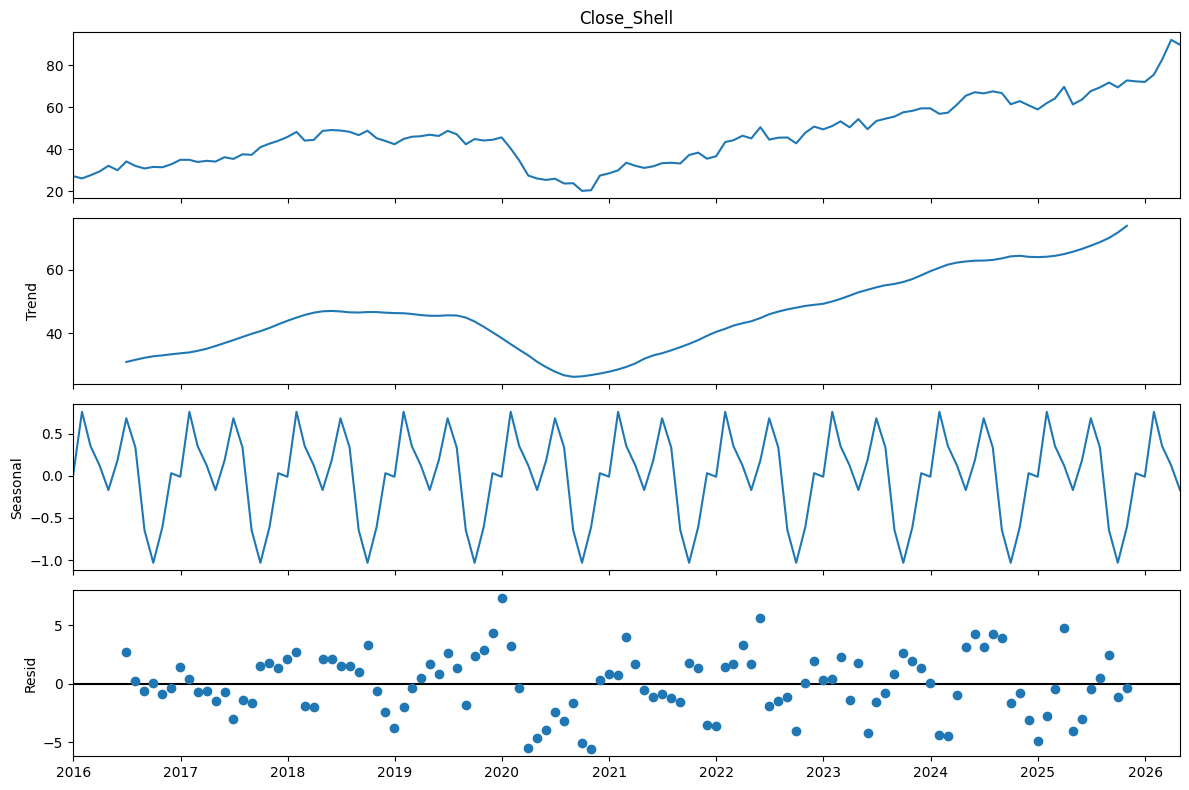

In [386]:
shell_monthly = samengevoegd_fil['Close_Shell'].asfreq('ME', method='pad')
decompose_result_Shell = seasonal_decompose(shell_monthly.dropna(), period=12)

df_trend = decompose_result_Shell.trend
df_season = decompose_result_Shell.seasonal
df_residual = decompose_result_Shell.resid

plt.rcParams['figure.figsize'] = (12, 8)
fig = decompose_result_Shell.plot()

De trend in de koers van Shell gedurende de periode januari 2016- vandaag is positief.<br>
De seizoenscomponent vertoont een duidelijk terugkerend patroon met afwisselend positieve en negatieve waarden. Dit wijst juist op een stabiele seizoensinvloed en niet op een random walk. Bij een random walk zou geen regelmatig herhalend patroon zichtbaar zijn.<br>
In de residugrafiek zijn de afwijkingen rond de trend en seizoenscomponent zichtbaar. Vanaf ongeveer 2020 lijken de uitslagen groter te worden dan in de beginperiode (2016–2018), wat kan wijzen op een toename van de volatiliteit of onzekerheid.

###Olie

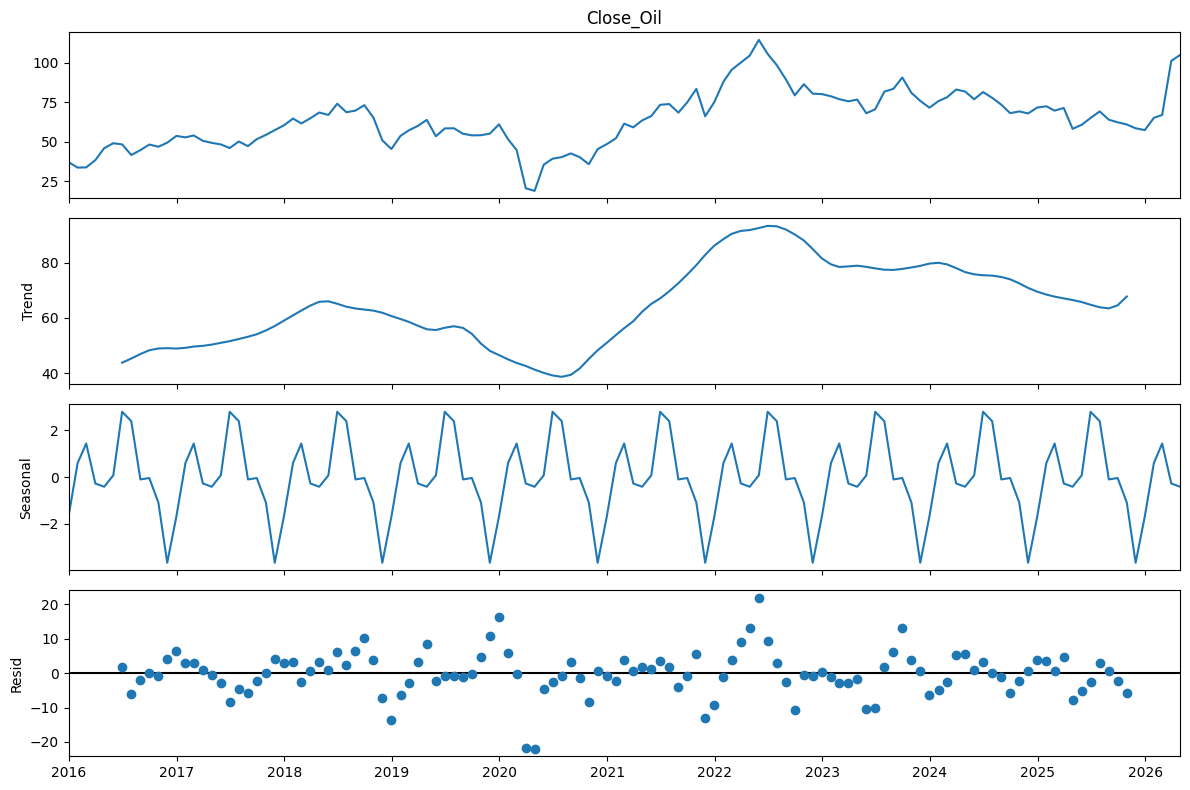

In [387]:
oil_monthly = samengevoegd_fil['Close_Oil'].asfreq('ME', method='pad')
decompose_result_Oil = seasonal_decompose(oil_monthly.dropna(), period=12)

df_trend_oil = decompose_result_Oil.trend
df_season_oil = decompose_result_Oil.seasonal
df_residual_oil = decompose_result_Oil.resid

plt.rcParams['figure.figsize'] = (12, 8)
fig = decompose_result_Oil.plot()

De trend in de olieprijs gedurende de periode 2016–2026 is wisselend. Er is een stijgende lijn zichtbaar tot ongeveer 2022, waarna de trend licht daalt, met een opvallende dip rond 2020 als gevolg van de COVID-19-crisis. <br>
De seizoensinvloed op de olieprijs is regelmatig afwisselend positief en negatief, dat duidt op een voorspelbare cyclische component in de prijs. <br>
In de grafiek van de residuen is te zien dat de afwijkingen rond 2020 en 2022 opvallend groot zijn. Er is meer onzekerheid ten aanzien van de olieprijs in die jaren dan in de periode 2016–2019.

###GDP

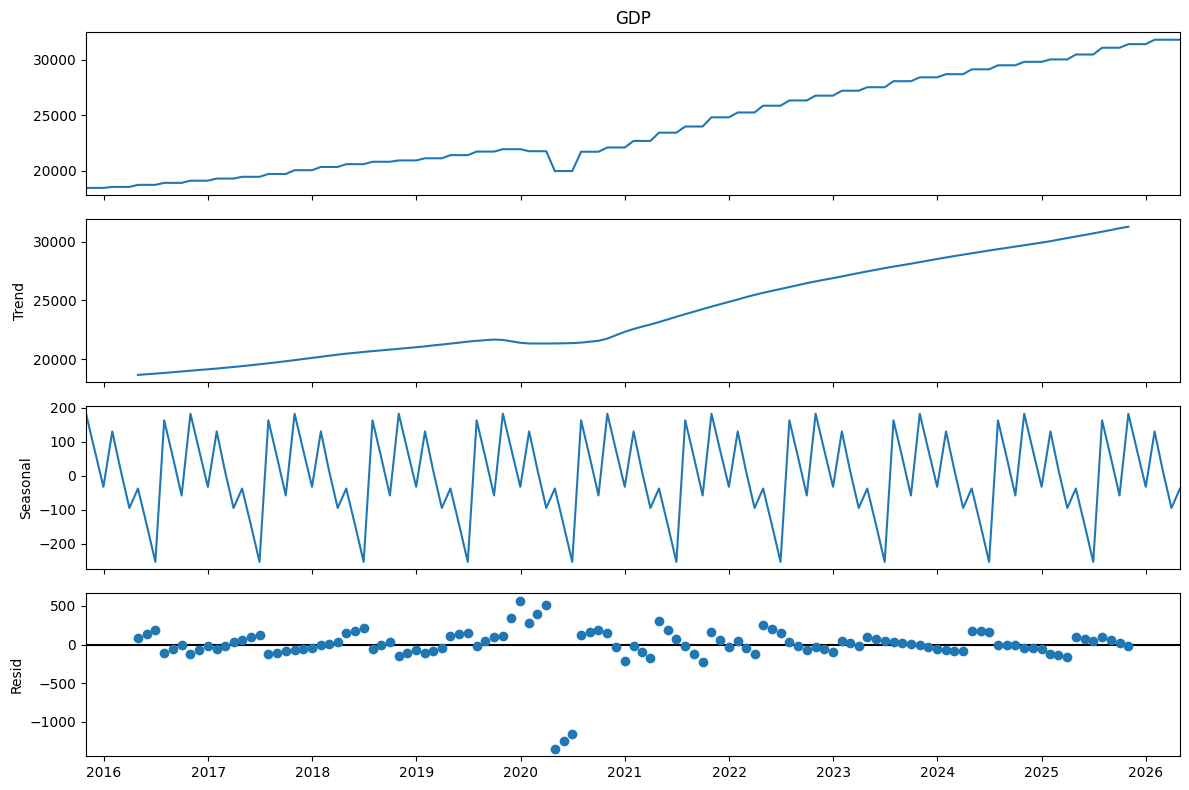

In [388]:
gdp_monthly = samengevoegd_fil['GDP'].asfreq('ME', method='pad')
decompose_result_GDP = seasonal_decompose(gdp_monthly.dropna(), period=12)

df_trend_gdp = decompose_result_GDP.trend
df_season_gdp = decompose_result_GDP.seasonal
df_residual_gdp = decompose_result_GDP.resid

plt.rcParams['figure.figsize'] = (12, 8)
fig = decompose_result_GDP.plot()

De tijdreeksanalyse van het GDP laat een duidelijke stijgende trend zien van 2016 tot 2025. Rond 2020 is een sterke daling zichtbaar, waarna het GDP zich snel herstelt en verder groeit. De seizoenscomponent toont terugkerende jaarlijkse schommelingen. De residuen liggen meestal rond de nullijn, behalve in 2020 waar grote afwijkingen zichtbaar zijn. <br>

###tabular presentation year-end close composition

In [389]:
def print_time_series_table(data_dict):
    """
    Print time series data in a tabular format.

    Parameters:
    data_dict (dict): Dictionary with row labels as keys and series of values as values,
                      including a 'dates' key for the column headers
    """
    # Print each row of data
    for label, values in data_dict.items():
        print(f"{label:20}", end='')
        # Format each value
        for value in values:
            if isinstance(value, dt.datetime):  # Check if value is datetime
                print(f"{value.strftime('%d-%m-%Y'):>20}", end='')
            else:  # Treat as float
                print(f"{value:>20.3f}", end='')
        print()

year_end_dates = [dt.datetime(year, 12, 31) for year in range(samengevoegd_fil.index.min().year, end.year)]

data_to_print = {
    'Date': year_end_dates,
    'Close_Shell ($)': samengevoegd_fil['Close_Shell'].loc[year_end_dates],
    'Trend ($)': decompose_result_Shell.trend.loc[year_end_dates],
    'Seasonality ($)': decompose_result_Shell.seasonal.loc[year_end_dates],
    'Residual ($)': decompose_result_Shell.resid.loc[year_end_dates]
}

print_time_series_table(data_to_print)

Date                          31-12-2015          31-12-2016          31-12-2017          31-12-2018          31-12-2019          31-12-2020          31-12-2021          31-12-2022          31-12-2023          31-12-2024          31-12-2025
Close_Shell ($)                   27.337              35.062              45.939              42.488              45.763              28.630              36.768              49.567              59.576              59.056              72.146
Trend ($)                            nan              33.625              43.884              46.319              38.439              27.815              40.388              49.251              59.529              63.977                 nan
Seasonality ($)                   -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012
Residual ($)                        

In [390]:
year_end_dates = [dt.datetime(year, 12, 31) for year in range(samengevoegd_fil.index.min().year, end.year)]

data_to_print = {
    'Date': year_end_dates,
    'Close_Oil ($)': samengevoegd_fil['Close_Oil'].loc[year_end_dates],
    'Trend ($)': decompose_result_Oil.trend.loc[year_end_dates],
    'Seasonality ($)': decompose_result_Oil.seasonal.loc[year_end_dates],
    'Residual ($)': decompose_result_Oil.resid.loc[year_end_dates]
}

print_time_series_table(data_to_print)

Date                          31-12-2015          31-12-2016          31-12-2017          31-12-2018          31-12-2019          31-12-2020          31-12-2021          31-12-2022          31-12-2023          31-12-2024          31-12-2025
Close_Oil ($)                     37.040              53.720              60.420              45.410              61.060              48.520              75.210              80.260              71.650              71.720              57.420
Trend ($)                            nan              48.901              59.024              60.694              46.513              50.990              86.297              81.638              79.762              69.559                 nan
Seasonality ($)                   -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693
Residual ($)                        

In [391]:
year_end_dates = [dt.datetime(year, 12, 31) for year in range(samengevoegd_fil.index.min().year, end.year)]

# Filter year_end_dates to only include dates present in decompose_result_GDP.trend
# This is necessary because seasonal_decompose introduces NaNs at the beginning/end
# and dropna() before seasonal_decompose might further alter the start date.
# The intersection will ensure only valid dates are used for indexing.
valid_year_end_dates = decompose_result_GDP.trend.index.intersection(year_end_dates)

data_to_print = {
    'Date': valid_year_end_dates,
    'Income ($)': samengevoegd_fil['GDP'].loc[valid_year_end_dates],
    'Trend ($)': decompose_result_GDP.trend.loc[valid_year_end_dates],
    'Seasonality ($)': decompose_result_GDP.seasonal.loc[valid_year_end_dates],
    'Residual ($)': decompose_result_GDP.resid.loc[valid_year_end_dates]
}

print_time_series_table(data_to_print)

Date                          31-12-2015          31-12-2016          31-12-2017          31-12-2018          31-12-2019          31-12-2020          31-12-2021          31-12-2022          31-12-2023          31-12-2024          31-12-2025
Income ($)                     18435.137           19089.379           20037.088           20917.867           21933.217           22087.160           24813.600           26770.514           28424.722           29825.182           31422.526
Trend ($)                            nan           19144.897           20112.192           21022.491           21399.965           22330.066           24875.430           26893.798           28521.319           29910.393                 nan
Seasonality ($)                  -32.672             -32.672             -32.672             -32.672             -32.672             -32.672             -32.672             -32.672             -32.672             -32.672             -32.672
Residual ($)                        

###Seizoensinvloed koers Shell?
We gaan onderzoeken of er een maand-effect te vinden is in de koersdata van Shell. Eerst maken we een nieuw dataframe waarop we de regressie kunnen draaien.

In [392]:
seizoen_Shell = samengevoegd_fil['Close_Shell'].reset_index().reset_index()
seizoen_Shell['Month'] = pd.DatetimeIndex(seizoen_Shell['index']).month
seizoen_Shell = seizoen_Shell.rename(columns = {'level_0' : 'Time'})
seizoen_Shell

,Time,index,Close_Shell,Month
0,0,2015-10-01,NaN,10
1,1,2015-12-01,NaN,12
2,2,2015-12-25,NaN,12
3,3,2015-12-26,NaN,12
4,4,2015-12-27,NaN,12
...,...,...,...,...
3802,3802,2026-05-21,86.148804,5
3803,3803,2026-05-22,85.709999,5
3804,3804,2026-05-23,85.709999,5
3805,3805,2026-05-24,85.709999,5


In [393]:
for i in range(1,12):
  seizoen_Shell["M" + str(i)] = np.where(seizoen_Shell["Month"] == i, 1,0)
seizoen_Shell

,Time,index,Close_Shell,Month,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,2015-10-01,NaN,10,0,0,0,0,0,0,0,0,0,1,0
1,1,2015-12-01,NaN,12,0,0,0,0,0,0,0,0,0,0,0
2,2,2015-12-25,NaN,12,0,0,0,0,0,0,0,0,0,0,0
3,3,2015-12-26,NaN,12,0,0,0,0,0,0,0,0,0,0,0
4,4,2015-12-27,NaN,12,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3802,3802,2026-05-21,86.148804,5,0,0,0,0,1,0,0,0,0,0,0
3803,3803,2026-05-22,85.709999,5,0,0,0,0,1,0,0,0,0,0,0
3804,3804,2026-05-23,85.709999,5,0,0,0,0,1,0,0,0,0,0,0
3805,3805,2026-05-24,85.709999,5,0,0,0,0,1,0,0,0,0,0,0


In [394]:
X_Shell = seizoen_Shell.copy()
X_Shell.drop(seizoen_Shell.columns[[1, 2, 3]], axis = 1, inplace= True)
X_Shell

,Time,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3802,3802,0,0,0,0,1,0,0,0,0,0,0
3803,3803,0,0,0,0,1,0,0,0,0,0,0
3804,3804,0,0,0,0,1,0,0,0,0,0,0
3805,3805,0,0,0,0,1,0,0,0,0,0,0


In [395]:
y_Shell = seizoen_Shell[seizoen_Shell.columns[2]]
y_Shell

,Close_Shell
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3802,86.148804
3803,85.709999
3804,85.709999
3805,85.709999


In [396]:
mask = y_Shell.notna() & X_Shell.notna().all(axis=1)
reg = sm.OLS(y_Shell[mask], X_Shell[mask]).fit()
print(reg.summary())

                                 OLS Regression Results                                
Dep. Variable:            Close_Shell   R-squared (uncentered):                   0.945
Model:                            OLS   Adj. R-squared (uncentered):              0.945
Method:                 Least Squares   F-statistic:                              5409.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):                        0.00
Time:                        10:48:23   Log-Likelihood:                         -14693.
No. Observations:                3802   AIC:                                  2.941e+04
Df Residuals:                    3790   BIC:                                  2.948e+04
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

We zien dat het model niet geldig is: de p-waarden van M1, M6, M7, M8, M9, M10 en M11 zijn groter dan 0,05. <br>
De coefficient van de Tijd is klein maar positief: er is een lichte opwaartse trend in de koersdata van Shell.

###Seizoensinvloed koers Olie?
We gaan onderzoeken of er een maand-effect te vinden is in de koersdata van Olie. Eerst maken we een nieuw dataframe waarop we de regressie kunnen draaien.

In [397]:
seizoen_Oil = samengevoegd_fil['Close_Oil'].reset_index().reset_index()
seizoen_Oil['Month'] = pd.DatetimeIndex(seizoen_Oil['index']).month
seizoen_Oil = seizoen_Oil.rename(columns = {'level_0' : 'Time'})
seizoen_Oil

,Time,index,Close_Oil,Month
0,0,2015-10-01,NaN,10
1,1,2015-12-01,NaN,12
2,2,2015-12-25,NaN,12
3,3,2015-12-26,NaN,12
4,4,2015-12-27,NaN,12
...,...,...,...,...
3802,3802,2026-05-21,96.349998,5
3803,3803,2026-05-22,96.599998,5
3804,3804,2026-05-23,96.599998,5
3805,3805,2026-05-24,96.599998,5


In [398]:
for i in range(1,12):
  seizoen_Oil["M" + str(i)] = np.where(seizoen_Oil["Month"] == i, 1,0)
seizoen_Oil

,Time,index,Close_Oil,Month,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,2015-10-01,NaN,10,0,0,0,0,0,0,0,0,0,1,0
1,1,2015-12-01,NaN,12,0,0,0,0,0,0,0,0,0,0,0
2,2,2015-12-25,NaN,12,0,0,0,0,0,0,0,0,0,0,0
3,3,2015-12-26,NaN,12,0,0,0,0,0,0,0,0,0,0,0
4,4,2015-12-27,NaN,12,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3802,3802,2026-05-21,96.349998,5,0,0,0,0,1,0,0,0,0,0,0
3803,3803,2026-05-22,96.599998,5,0,0,0,0,1,0,0,0,0,0,0
3804,3804,2026-05-23,96.599998,5,0,0,0,0,1,0,0,0,0,0,0
3805,3805,2026-05-24,96.599998,5,0,0,0,0,1,0,0,0,0,0,0


In [399]:
X_Oil = seizoen_Oil.copy()
X_Oil.drop(seizoen_Oil.columns[[1, 2, 3]], axis = 1, inplace= True)
X_Oil

,Time,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3802,3802,0,0,0,0,1,0,0,0,0,0,0
3803,3803,0,0,0,0,1,0,0,0,0,0,0
3804,3804,0,0,0,0,1,0,0,0,0,0,0
3805,3805,0,0,0,0,1,0,0,0,0,0,0


In [400]:
y_Oil = seizoen_Oil[seizoen_Oil.columns[2]]
y_Oil

,Close_Oil
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3802,96.349998
3803,96.599998
3804,96.599998
3805,96.599998


In [401]:
mask = y_Oil.notna() & X_Oil.notna().all(axis=1)
reg = sm.OLS(y_Oil[mask], X_Oil[mask]).fit()
print(reg.summary())

                                 OLS Regression Results                                
Dep. Variable:              Close_Oil   R-squared (uncentered):                   0.927
Model:                            OLS   Adj. R-squared (uncentered):              0.927
Method:                 Least Squares   F-statistic:                              4015.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):                        0.00
Time:                        10:48:23   Log-Likelihood:                         -16390.
No. Observations:                3802   AIC:                                  3.280e+04
Df Residuals:                    3790   BIC:                                  3.288e+04
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

We zien dat het model niet geldig is: de p-waarden van M1, M2 en M11 zijn groter dan 0,05. <br>
De coefficient van de Tijd is klein maar positief: er is een lichte opwaartse trend in de koersdata van Olie.

###Seizoensinvloed koers GDP?
We gaan onderzoeken of er een maand-effect te vinden is in de koersdata van het GPD. Eerst maken we een nieuw dataframe waarop we de regressie kunnen draaien.

In [402]:
seizoen_GDP = samengevoegd_fil['GDP'].reset_index().reset_index()
seizoen_GDP['Month'] = pd.DatetimeIndex(seizoen_GDP['index']).month
seizoen_GDP = seizoen_GDP.rename(columns = {'level_0' : 'Time'})
seizoen_GDP

,Time,index,GDP,Month
0,0,2015-10-01,18435.137,10
1,1,2015-12-01,18435.137,12
2,2,2015-12-25,18435.137,12
3,3,2015-12-26,18435.137,12
4,4,2015-12-27,18435.137,12
...,...,...,...,...
3802,3802,2026-05-21,31819.464,5
3803,3803,2026-05-22,31819.464,5
3804,3804,2026-05-23,31819.464,5
3805,3805,2026-05-24,31819.464,5


In [403]:
for i in range(1,12):
  seizoen_GDP["M" + str(i)] = np.where(seizoen_GDP["Month"] == i, 1,0)
seizoen_GDP

,Time,index,GDP,Month,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,2015-10-01,18435.137,10,0,0,0,0,0,0,0,0,0,1,0
1,1,2015-12-01,18435.137,12,0,0,0,0,0,0,0,0,0,0,0
2,2,2015-12-25,18435.137,12,0,0,0,0,0,0,0,0,0,0,0
3,3,2015-12-26,18435.137,12,0,0,0,0,0,0,0,0,0,0,0
4,4,2015-12-27,18435.137,12,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3802,3802,2026-05-21,31819.464,5,0,0,0,0,1,0,0,0,0,0,0
3803,3803,2026-05-22,31819.464,5,0,0,0,0,1,0,0,0,0,0,0
3804,3804,2026-05-23,31819.464,5,0,0,0,0,1,0,0,0,0,0,0
3805,3805,2026-05-24,31819.464,5,0,0,0,0,1,0,0,0,0,0,0


In [404]:
X_GDP = seizoen_GDP.copy()
X_GDP.drop(seizoen_GDP.columns[[1, 2, 3]], axis = 1, inplace= True)
X_GDP

,Time,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3802,3802,0,0,0,0,1,0,0,0,0,0,0
3803,3803,0,0,0,0,1,0,0,0,0,0,0
3804,3804,0,0,0,0,1,0,0,0,0,0,0
3805,3805,0,0,0,0,1,0,0,0,0,0,0


In [405]:
y_GDP = seizoen_GDP[seizoen_GDP.columns[2]]
y_GDP

,GDP
0,18435.137
1,18435.137
2,18435.137
3,18435.137
4,18435.137
...,...
3802,31819.464
3803,31819.464
3804,31819.464
3805,31819.464


In [406]:
mask = y_GDP.notna() & X_GDP.notna().all(axis=1)
reg = sm.OLS(y_GDP[mask], X_GDP[mask]).fit()
print(reg.summary())

                                 OLS Regression Results                                
Dep. Variable:                    GDP   R-squared (uncentered):                   0.967
Model:                            OLS   Adj. R-squared (uncentered):              0.967
Method:                 Least Squares   F-statistic:                              9399.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):                        0.00
Time:                        10:48:23   Log-Likelihood:                         -37377.
No. Observations:                3807   AIC:                                  7.478e+04
Df Residuals:                    3795   BIC:                                  7.485e+04
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

We zien dat het model niet geldig is: de p-waarden van M3, M4, M5, M8, M9 en M11 zijn groter dan 0,05. <br>
De coefficient van de Tijd is positief: er is een opwaartse trend in de koersdata van GDP.

##4b Time Series - Resampling

Bij dit onderdeel wordt de koersvolatiliteit van **Close_Gold** product geanalyseerd op verschillende tijdschalen, zoals seconden, uren, dagen, weken en maanden. Met behulp van resampling wordt de ruwe prijsdata geaggregeerd naar elk tijdsniveau, waarna per tijdschaal de volatiliteit wordt berekend — doorgaans als de standaarddeviatie van de procentuele rendementen. Het doel is te onderzoeken of de gemeten volatiliteit significant verschilt afhankelijk van de gekozen tijdschaal, en dus of tijdsniveau een bepalende factor is in hoe beweeglijk een koers lijkt.

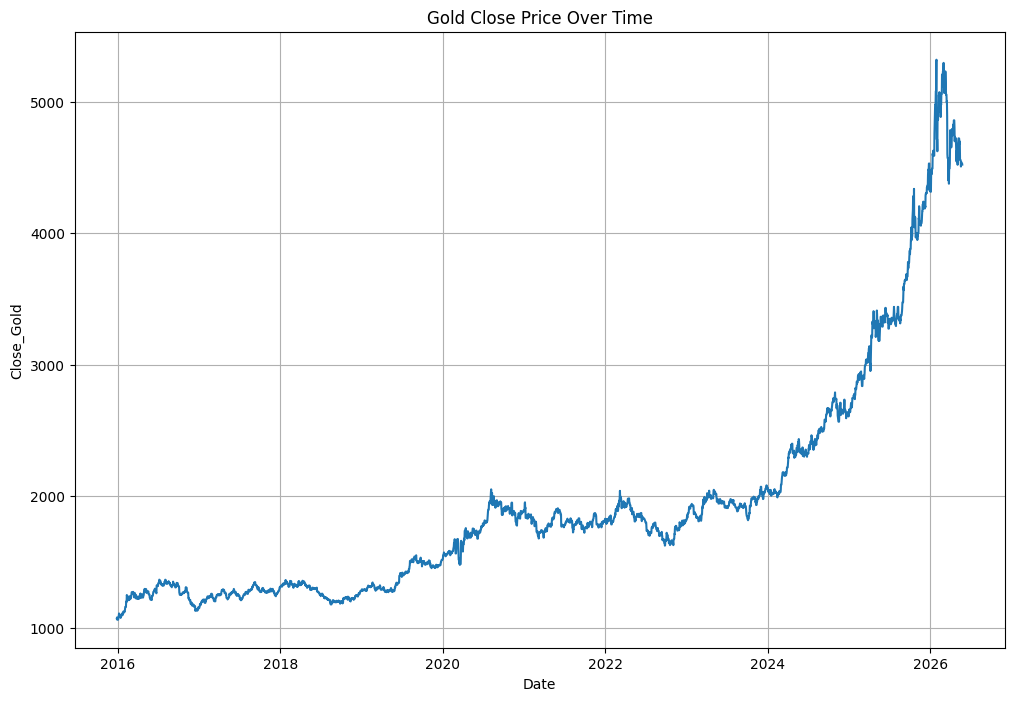

In [407]:
plt.plot(data.index, data['Close_Gold'])
plt.xlabel('Date')
plt.ylabel('Close_Gold')
plt.title('Gold Close Price Over Time')
plt.grid(True)
plt.show()

<Axes: >

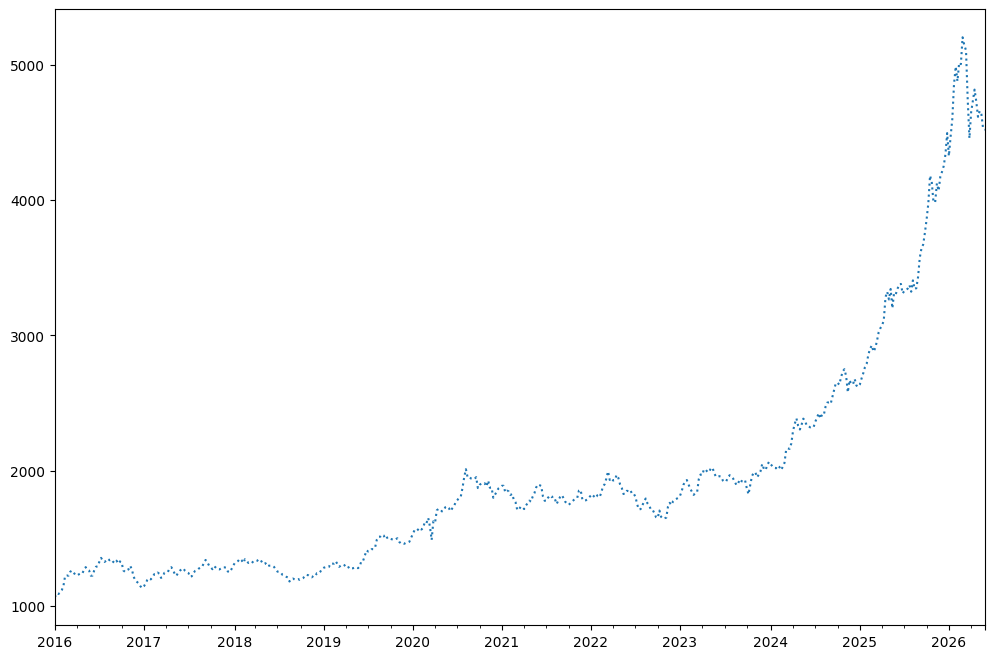

In [408]:
weekly = data['Close_Gold'].resample('W').mean()
weekly.plot(style=[':'])

<Axes: >

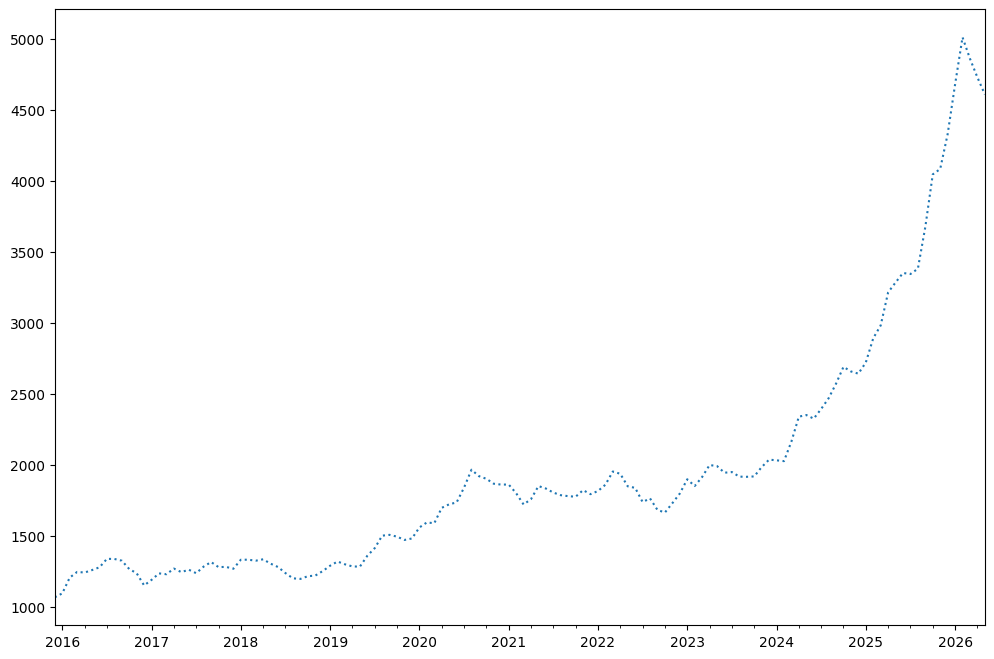

In [409]:
monthly = data['Close_Gold'].resample('ME').mean()
monthly.plot(style=[':'])

<Axes: >

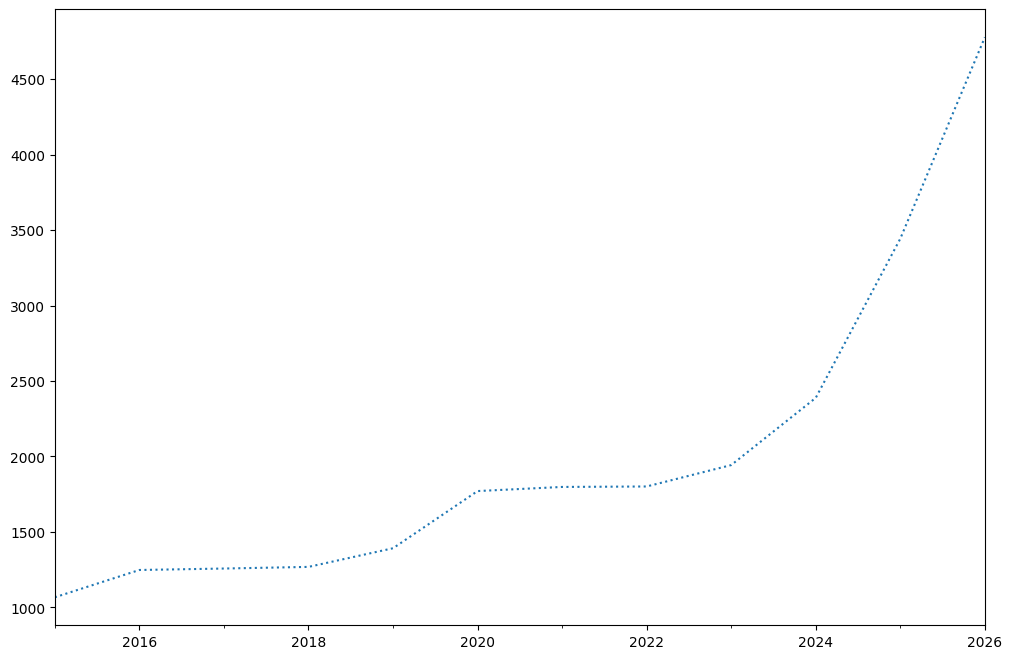

In [410]:
yearly = data['Close_Gold'].resample('YE').mean()
yearly.plot(style=[':'])

In [411]:
ticker = yf.Ticker("GC=F")

Gold_data = ticker.history(interval="1h", start="2025-1-01", end=end)

In [412]:
Gold_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-01-02 00:00:00-05:00,2645.800049,2648.800049,2645.100098,2646.000000,2454,0.0,0.0
2025-01-02 01:00:00-05:00,2646.000000,2647.800049,2643.600098,2646.500000,2488,0.0,0.0
2025-01-02 02:00:00-05:00,2646.399902,2648.000000,2644.699951,2647.899902,1936,0.0,0.0
2025-01-02 03:00:00-05:00,2648.000000,2650.199951,2642.600098,2648.800049,5375,0.0,0.0
2025-01-02 04:00:00-05:00,2649.000000,2652.899902,2648.899902,2649.000000,4311,0.0,0.0


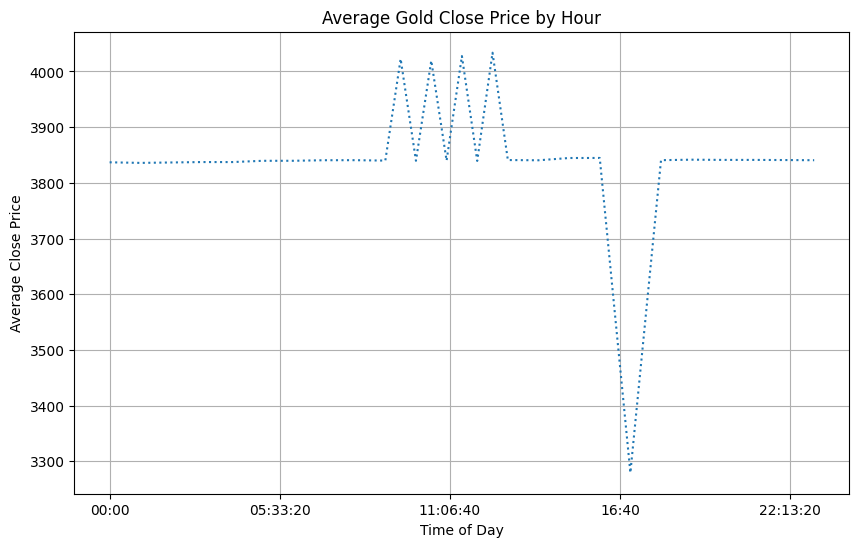

In [413]:
# look at average gold price by hour
# transform Gold_data by using of groupby

# Check if 'Gold_data' is empty. Gold_data is expected to be loaded from previous cells.
if not Gold_data.empty:
    # Group by the time component of the DatetimeIndex and calculate the mean 'Close' price
    by_time = Gold_data['Close'].groupby(Gold_data.index.time).mean()

    plt.figure(figsize=(10, 6)) # Add a figure for proper plot display
    by_time.plot(style=[':']);
    plt.xlabel('Time of Day')
    plt.ylabel('Average Close Price')
    plt.title('Average Gold Close Price by Hour')
    plt.grid(True)
    plt.show() # Make sure the plot is shown
else:
    # If Gold_data is unexpectedly empty, print a warning.
    print("Warning: Gold_data is empty. Cannot plot hourly trends.")

De grafiek lijkt een duidelijk intraday-patroon te tonen: een stabiel basisniveau rond ~\$3.830 gedurende het grootste deel van de dag, een opvallende piek naar ~\$4.000–\$4.025 rond het middaguur, en een scherpe dip naar ~\$3.300 rond 17:00.
Deze pieken en dip zijn echter verdacht: ze wijken sterk af van het verder vlakke verloop en vallen samen met afwijkende tijdstippen (zoals 09:30, 11:30 en 17:00). Voordat we hier een handelspatroon uit afleiden, controleren we daarom hoeveel metingen er achter elk tijdstip zitten.

In [414]:
g = Gold_data.copy()

print("1) Basisinfo van de uurdata")
print("-" * 50)
print(f"Aantal rijen:        {len(g)}")
print(f"Periode:             {g.index.min()}  t/m  {g.index.max()}")
print(f"Tijdzone van index:  {g.index.tz}")
print(f"NaN's in 'Close':    {g['Close'].isna().sum()}")
print(f"Nullen in 'Close':   {(g['Close'] == 0).sum()}")
print()

# 2) Hoeveel observaties liggen achter ELK tijdstip in de 'by_time'-grafiek?
#    Een dip die op weinig metingen rust, is verdacht.
by_time_mean  = g['Close'].groupby(g.index.time).mean()
by_time_count = g['Close'].groupby(g.index.time).count()
by_time_min   = g['Close'].groupby(g.index.time).min()
by_time_max   = g['Close'].groupby(g.index.time).max()

overzicht = pd.DataFrame({
    'gemiddelde': by_time_mean.round(2),
    'aantal':     by_time_count,
    'min':        by_time_min.round(2),
    'max':        by_time_max.round(2),
})
print("2) Gemiddelde, aantal metingen, min en max per tijdstip")
print("-" * 50)
print(overzicht)
print()

1) Basisinfo van de uurdata
--------------------------------------------------
Aantal rijen:        7995
Periode:             2025-01-02 00:00:00-05:00  t/m  2026-05-22 16:00:00-04:00
Tijdzone van index:  America/New_York
NaN's in 'Close':    0
Nullen in 'Close':   0

2) Gemiddelde, aantal metingen, min en max per tijdstip
--------------------------------------------------
          gemiddelde  aantal     min     max
00:00:00     3836.88     348  2645.2  5590.9
01:00:00     3835.82     348  2643.6  5591.0
02:00:00     3836.56     348  2638.7  5578.4
03:00:00     3837.33     348  2643.6  5540.6
04:00:00     3837.30     348  2644.9  5544.8
05:00:00     3839.58     349  2645.8  5514.1
06:00:00     3839.62     349  2654.6  5553.5
07:00:00     3840.61     349  2656.4  5564.5
08:00:00     3840.70     349  2634.5  5540.3
09:00:00     3839.95     349  2643.2  5525.3
09:30:00     4022.60       3  3342.4  4491.9
10:00:00     3839.63     349  2645.5  5329.6
10:30:00     4019.47       3  3334.3  4

Deze cel onderzoekt of het patroon in de grafiek echt is of een meetartefact. Vier stappen:

*   **Basisinfo** - controleert de periode, de tijdzone van de index (America/New_York) en of er geen ontbrekende of nulwaarden in de koers zitten.<br>
*   **Aantal metingen per tijdstip** - dit is de kern. Het gemiddelde per uur is alleen betrouwbaar als er voldoende metingen achter zitten. Tijdstippen met maar een paar waarnemingen geven een vertekend gemiddelde.<br>
* **Inzoomen op de dip** - bekijkt welke losse koersen het laagste gemiddelde veroorzaken.<br>
* **Gemiddelde vs. mediaan** - een grote afwijking tussen beide wijst op uitschieters.<p>





Uit de output blijkt dat de meeste uren ~340–349 metingen hebben, maar dat 09:30, 10:30, 11:30, 12:30 elk slechts 3 metingen hebben en 17:00 zelfs maar 2. De "dip" op 17:00 berust dus op twee koersen (\$3.180,70 en \$3.378,00) en de "piek" rond het middaguur op telkens drie. Dat zijn geen volwaardige uurgemiddelden.

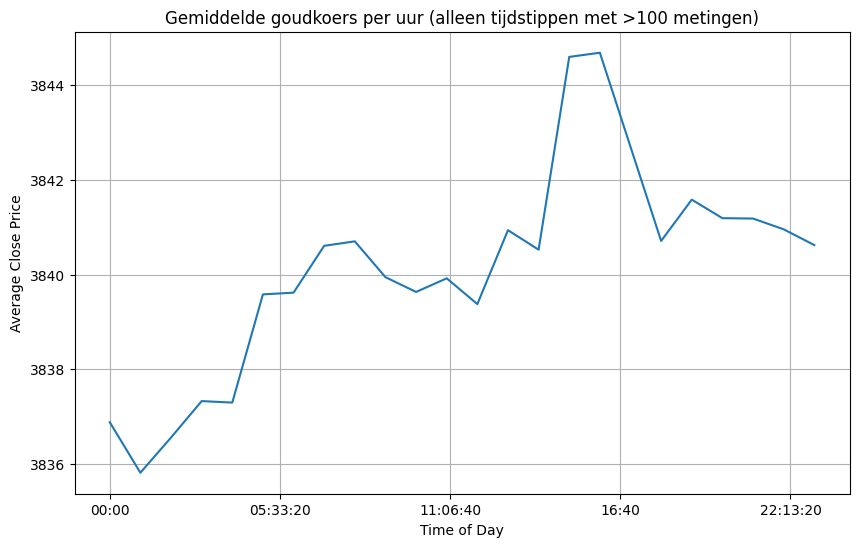

In [415]:
# Alleen tijdstippen met voldoende metingen meenemen, zodat
# onderbemeten tijdstippen het gemiddelde niet vertekenen.
counts = g['Close'].groupby(g.index.time).count()
geldige_tijden = set(counts[counts > 100].index)   # drempel naar smaak
mask = g.index.map(lambda t: t.time() in geldige_tijden)
g_schoon = g[mask]

by_time_schoon = g_schoon['Close'].groupby(g_schoon.index.time).mean()

plt.figure(figsize=(10, 6))
by_time_schoon.plot(style=['-'])
plt.xlabel('Time of Day')
plt.ylabel('Average Close Price')
plt.title('Gemiddelde goudkoers per uur (alleen tijdstippen met >100 metingen)')
plt.grid(True)
plt.show()

Na het verwijderen van de onderbemeten tijdstippen verdwijnen zowel de piek rond het middaguur als de scherpe dip rond 17:00. Wat overblijft is een vrijwel vlakke lijn: het gemiddelde uurgemiddelde van de goudkoers ligt over de hele dag stabiel tussen ~/$3.836 en ~/$3.845.
De goud-uurdata van GC=F vertoont over de periode januari 2025 – mei 2026 dus nauwelijks een intraday-patroon. De pieken en dip in de oorspronkelijke grafiek waren geen handelspatroon, maar een artefact van enkele tijdstippen (09:30, 11:30, 12:30 en 17:00) waarvoor Yahoo Finance maar 2 à 3 waarnemingen teruggaf. Het gemiddelde over zo weinig punten is statistisch niet betekenisvol.
De eerdere interpretatie — een ochtendpiek door de opening van de Londense/New Yorkse markten en een dip door een nieuwsgebeurtenis — gaat daarmee niet op. De les is dat een gemiddelde altijd samen met het aantal onderliggende metingen beoordeeld moet worden.

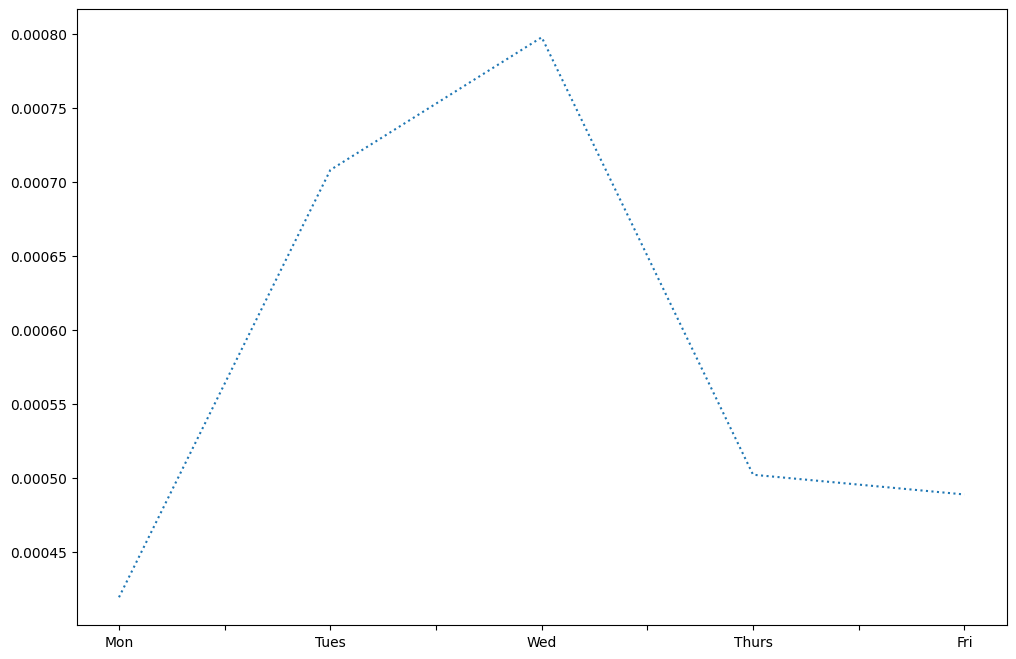

In [416]:
samengevoegd_fil['Return'] = samengevoegd_fil['Close_Gold'].pct_change()
by_weekday = samengevoegd_fil['Return'].groupby(samengevoegd_fil.index.dayofweek).mean()
by_weekday = by_weekday[by_weekday.index < 5]
by_weekday.index = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri']
by_weekday.plot(style=[':']);

Het gemiddelde rendement stijgt van **maandag** naar een piek op
**woensdag**, om daarna scherp te dalen naar een stabiel niveau op
**donderdag en vrijdag**. Woensdag is daarmee de sterkste handelsdag
voor goud in deze periode, mogelijk gerelateerd aan wekelijkse macro-economische publicaties zoals de Fed-notulen.

In [417]:
# Bereken rendementen per tijdsniveau
daily_returns = data['Close_Gold'].resample('D').last().pct_change()
weekly_returns = data['Close_Gold'].resample('W').last().pct_change()
monthly_returns = data['Close_Gold'].resample('ME').last().pct_change()
yearly_returns = data['Close_Gold'].resample('YE').last().pct_change()

# Bereken volatiliteit (sigma = standaarddeviatie)
sigma_daily = daily_returns.std()
sigma_weekly = weekly_returns.std()
sigma_monthly = monthly_returns.std()
sigma_yearly = yearly_returns.std()

print(f"Dag σ: {sigma_daily:.4f}")
print(f"Week σ: {sigma_weekly:.4f}")
print(f"Maand σ: {sigma_monthly:.4f}")
print(f"Jaar σ: {sigma_yearly:.4f}")

Dag σ: 0.0086
Week σ: 0.0216
Maand σ: 0.0419
Jaar σ: 0.1935


Om het verschil in volatiliteit tussen tijdsniveaus objectief te vergelijken is de standaarddeviatie (σ) van de rendementen berekend. De standaarddeviatie fungeert hierbij als maat voor volatiliteit: hoe hoger σ, hoe groter de gemiddelde afwijking van rendementen en dus hoe volatieler de koers. Uit de berekeningen blijkt dat de volatiliteit verschilt per tijdsniveau. Hierdoor kan worden geconcludeerd dat de gekozen tijdschaal invloed heeft op hoe beweeglijk de koers van goud wordt waargenomen.

##4d Timeshift

Timeshift (of lag/lead) is het verschuiven van een tijdreeks om vertraagde relaties tussen variabelen te ontdekken — bijvoorbeeld of reclame-uitgaven pas twee weken later effect hebben op de verkoop. In pandas doe je dit met df['kolom'].shift(1) voor een stap terug, of shift(-1) voor een stap vooruit. Belangrijk aandachtspunt is data leakage: gebruik nooit een lead als voorspellende feature, want dan gebruik je toekomstige informatie die je in de praktijk nog niet hebt.


**Vraag:**<br> Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?<br>
**Hypothese:**<br>
Ho: Gasoline (x5) en Close_Oil (x6) hebben geen invloed op de koers van Close_Shell (y3).<br>
H1: Gasoline (x5) en/of Close_Oil (x6) heeft invloed op de koers van Close_Shell (y3).<p>
Sinds Timeshift niet goed werkt met meerdere variabelen gaan wij hier kijken naar de onafhankelijke variabelen apart.

In [418]:
#Plot demo
def plot_series_demo():

  # legends and annotations
  local_max = start
  offset = pd.Timedelta(30, 'D')

  ax[0].legend(['input'], loc=2)
  ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
  ax[0].axvline(local_max, alpha=0.3, color='red')

  ax[1].legend(['shift(30)'], loc=2)
  ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
  ax[1].axvline(local_max + offset, alpha=0.3, color='red')

  return

In [419]:
#Correlation
# van chi square naar r

def chisquare2correlation(x, y):
    """
    Demonstrate relationship between chi-square and correlation

    Parameters:
    x, y: arrays of continuous data
    """
    # Calculate Pearson correlation
    r, p_value = stats.pearsonr(x, y)

    # Calculate chi-square from correlation
    n = len(x)
    chi_square_from_r = n * (r ** 2)

    print(f"Sample size (n): {n}")
    print(f"Correlation coefficient (r): {r:.4f}")
    print(f"Chi-square calculated from r: {chi_square_from_r:.4f}")


In [420]:
#Granger
def test_granger_causality(df, maxlag=10):
    """
    Test Granger causality between two time series

    Parameters:
    df: pandas Dataframe with datetime index
    maxlag: int, maximum number of lags to test

    Returns:
    Dictionary containing test results
    """
    # Perform Granger causality tests in both directions
    print("Testing if Oil Futures (CL=F) Granger-causes Shell plc (SHEL):\n")
    gc_result1 = grangercausalitytests(df[['SHEL', 'CL=F']], maxlag=maxlag, verbose=False)

    # Extract and format results
    results = {
        'CL=F_causes_SHEL': {lag: gc_result1[lag][0]['ssr_chi2test'][1] for lag in range(1, maxlag + 1)},
    }

    return results

/tmp/ipykernel_430/2025333719.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Oil = data['Close_Oil'].asfreq(Move_interval, method='pad')
/tmp/ipykernel_430/2025333719.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Oil.shift(periods=Shift_Number, freq=Move_interval).plot(ax=ax[2])


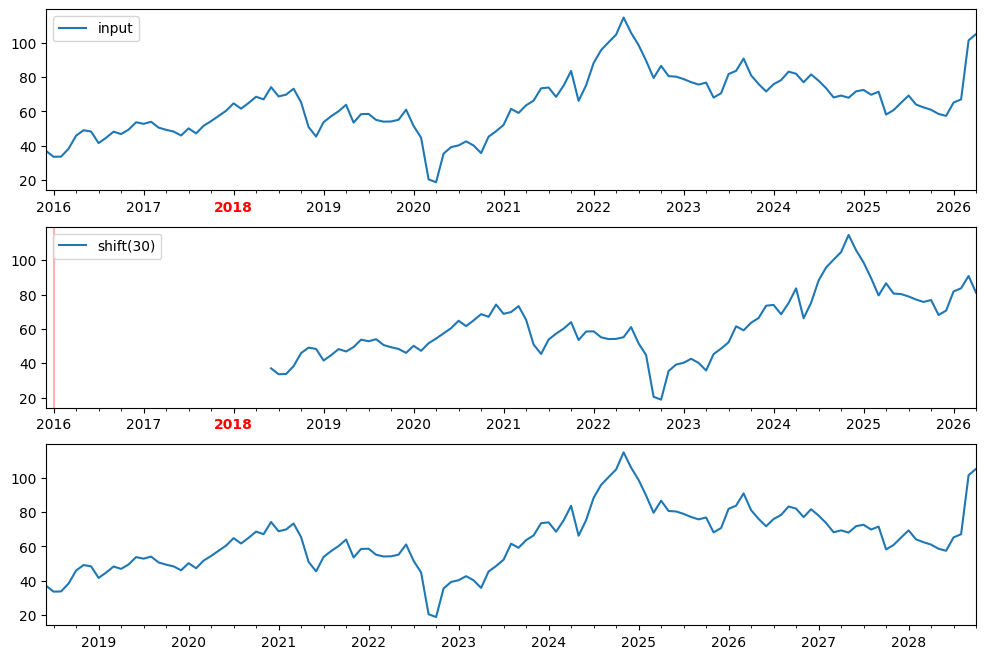

In [421]:
#@title Use of shift()
Move_interval = 'M'
Shift_Number = 30
fig, ax = plt.subplots(3, sharey=True)

# apply a frequency to the data
Oil = data['Close_Oil'].asfreq(Move_interval, method='pad')

Oil.plot(ax=ax[0])
Oil.shift(Shift_Number).plot(ax=ax[1])
Oil.shift(periods=Shift_Number, freq=Move_interval).plot(ax=ax[2])

plot_series_demo()

/tmp/ipykernel_430/2166340474.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  olie_daily = data['Close_Oil'].asfreq('M', method='pad')
/tmp/ipykernel_430/2166340474.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  shell_daily = data['Close_Shell'].asfreq('M', method='pad')


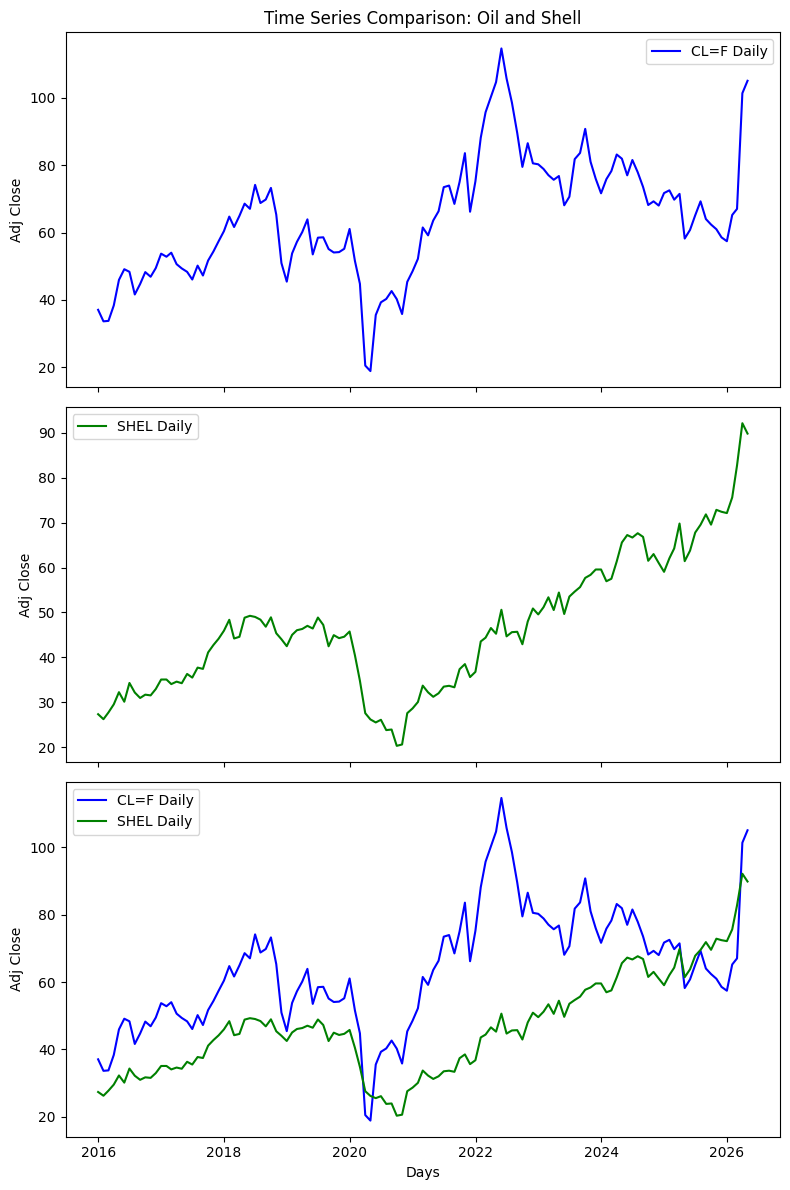

In [422]:
# @title Combine (concat)
olie_daily = data['Close_Oil'].asfreq('M', method='pad')
shell_daily = data['Close_Shell'].asfreq('M', method='pad')

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(olie_daily, label='CL=F Daily', color='blue')
axes[0].set_title('Time Series Comparison: Oil and Shell')
axes[0].set_ylabel('Adj Close')
axes[0].legend()

axes[1].plot(shell_daily, label='SHEL Daily', color='green')
axes[1].set_ylabel('Adj Close')
axes[1].legend()

axes[2].plot(olie_daily, label='CL=F Daily', color='blue')
axes[2].plot(shell_daily, label='SHEL Daily', color='green')
axes[2].set_ylabel('Adj Close')
axes[2].legend()

# Final adjustments
plt.xlabel('Days')
plt.tight_layout()
plt.show()

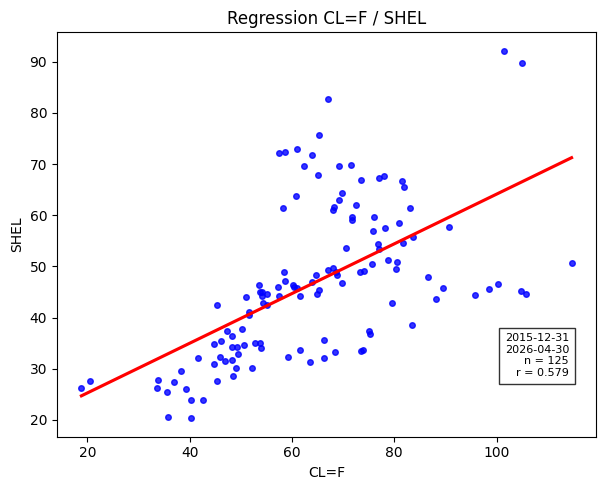

In [423]:
# @title plot cross correlation without lag

# Samenvoegen middels concat
portfolio = pd.concat([olie_daily, shell_daily], axis=1)
portfolio.columns = ['CL=F', 'SHEL']
portfolio.head(2)

# Prepare plot
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# Date range, n, correlation coefficient, p-value
start_date = portfolio.index[0].strftime('%Y-%m-%d')
end_date = portfolio.index[-1].strftime('%Y-%m-%d')
n = len(portfolio)
correlation = stats.pearsonr(portfolio['CL=F'], portfolio['SHEL'])[0]
pvalue = stats.pearsonr(portfolio['CL=F'], portfolio['SHEL'])[1]

# Create regression plot
sns.regplot(x='CL=F', y='SHEL', data=portfolio, ci=None, ax=ax,
            scatter_kws={'s': 16, 'alpha': .8, 'color': 'blue'},
            line_kws={'color': 'red'})
ax.set_aspect('equal')
ax.set_title('Regression CL=F / SHEL')
ax.text(0.95, 0.15, f'{start_date}\n{end_date}\nn = {n}\nr = {correlation:.3f}',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8),
        horizontalalignment='right',
        fontsize=8)

plt.tight_layout()

In [424]:
# @title create lag columns using shift

def make_lags(timeseries, lags, prefix='Lag'):
    return pd.concat(
        {
            f'{prefix}-{i}': timeseries.shift(-i)
            for i in range(1, lags + 1)
        },
        axis=1)


Xlag = make_lags(portfolio['CL=F'], lags=6, prefix='CL=F_Lag')
lags_df = pd.concat([portfolio, Xlag], axis=1)
lags_df.head(3)

,CL=F,SHEL,CL=F_Lag-1,CL=F_Lag-2,CL=F_Lag-3,CL=F_Lag-4,CL=F_Lag-5,CL=F_Lag-6
2015-12-31,37.040001,27.336702,33.619999,33.750000,38.340000,45.919998,49.099998,48.330002
2016-01-31,33.619999,26.226273,33.750000,38.340000,45.919998,49.099998,48.330002,41.599998
2016-02-29,33.750000,27.725687,38.340000,45.919998,49.099998,48.330002,41.599998,44.700001


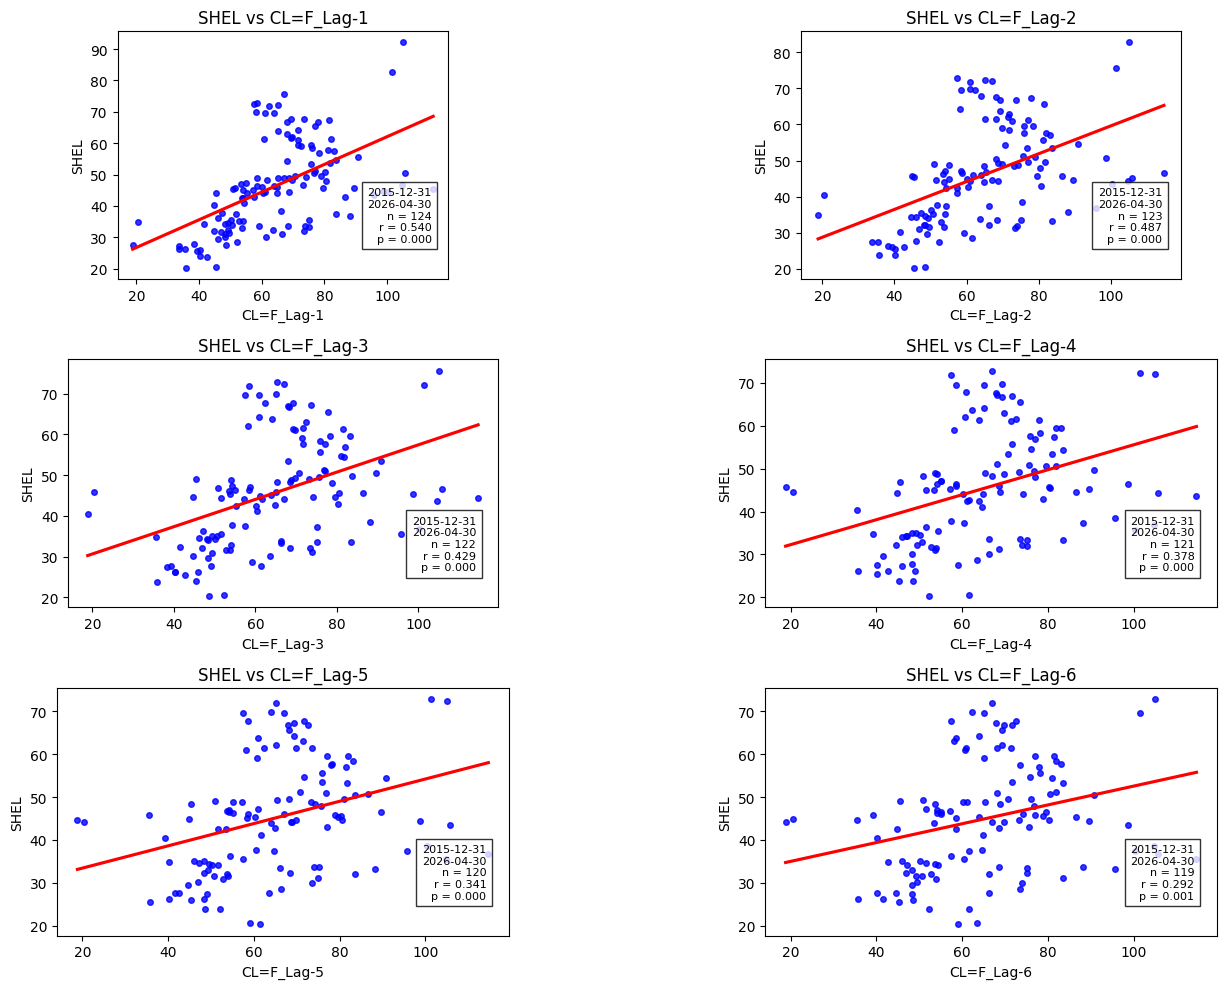

In [425]:
# @title plot cross correlation with lag

target_col = 'SHEL'
# Filter for only the lagged CL=F columns, excluding 'CL=F' itself and 'SHEL'
comparison_cols = [col for col in lags_df.columns if col.startswith('CL=F_Lag')]

# Calculate number of rows needed for subplot grid
n_plots = len(comparison_cols)
n_rows = (n_plots + 1) // 2  # Two plots per row, rounded up
n_cols = 2

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()  # Flatten to make indexing easier

# For each comparison column
for idx, col in enumerate(comparison_cols):
    # Calculate statistics
    valid_mask = ~(lags_df[target_col].isna() | lags_df[col].isna())  # Remove NaN values
    correlation, p_value = stats.pearsonr(lags_df[target_col][valid_mask], lags_df[col][valid_mask])
    n = valid_mask.sum()
    start_date = lags_df.index[0].strftime('%Y-%m-%d')
    end_date = lags_df.index[-1].strftime('%Y-%m-%d')

    # Create scatter plot with regression line
    sns.regplot(data=lags_df, x=col, y=target_col,
                scatter_kws={'s': 16, 'alpha': .8, 'color': 'blue'},
                line_kws={'color': 'red'},
                ci=None,
                ax=axes[idx])

    # Add text box with statistics
    axes[idx].text(0.95, 0.15,
                  f'{start_date}\n{end_date}\nn = {n}\nr = {correlation:.3f}\np = {p_value:.3f}',
                  transform=axes[idx].transAxes,
                  bbox=dict(facecolor='white', alpha=0.8),
                  horizontalalignment='right',
                  fontsize=8)

    # Set title
    axes[idx].set_title(f'{target_col} vs {col}')
    axes[idx].set_aspect('equal')

# Remove any empty subplots
for idx in range(len(comparison_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

Hierboven hebben we per shift (1,2,3,...) een correlatie coefficient laten berekenen. In dit voorbeeld is de hoogste correlatie coëfficient 0.532 (Close_Shell-Close_Oil).

<Figure size 1000x500 with 0 Axes>

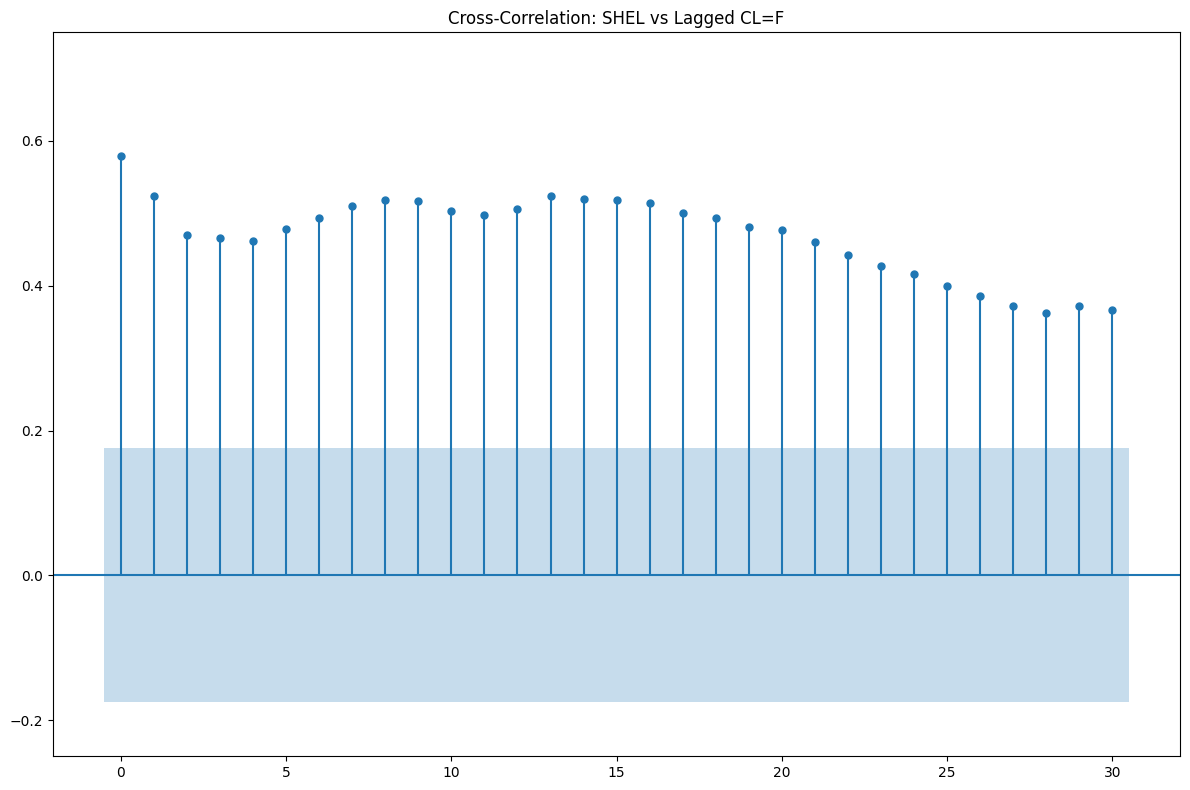

In [426]:
# @title lag-plot (or correlogram)
from statsmodels.graphics.tsaplots import plot_ccf
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 5))

# Plot CCF (Cross-Correlation Function)
plot_ccf(lags_df['SHEL'],
         lags_df['CL=F'],
         alpha=0.05,           # 95% confidence interval
         lags=30,              # number of lags to show
         title='Cross-Correlation: SHEL vs Lagged CL=F')

plt.ylim(-0.25, 0.75) # Set y-axis range
plt.tight_layout()
plt.show()

Deze grafiek toont de cross-correlatie tussen Close_Shell (Shell aandeel) en een lagged versie van de Close_Oil (Olie koers) tijdsreeks.<p>

* De x-as toont de lags (vertragingen) van 0 tot 30 (Hier is het in maanden)
* De y-as toont de correlatiecoëfficiënten, die kunnen variëren van -1 tot +1
* De blauwe stippen verbonden met verticale lijnen tonen de correlatie voor elke lag
* Het lichtblauwe gebied rondom 0 vertegenwoordigt het 95% betrouwbaarheidsinterval

Wat we kunnen zien:

* Bij lag 0 is er een correlatie van ongeveer 0.57
* De correlaties blijven redelijk consistent positief tussen de 0.4 en de 0.6 (behalve aan het einde)
* Alle correlaties zijn statistisch significant omdat ze buiten het blauwe betrouwbaarheidsinterval vallen
* Er is een duidelijke afname van correlatie naarmate de lag toeneemt<p>

De cross-correlatie tussen SHEL en de vertraagde CL=F reeks toont een consistent positief en statistisch significant patroon over alle getoonde lags:<p>

* Er een sterke mate van persistentie is in de relatie tussen de twee reeksen
* Historische waarden blijven voorspellende waarde redelijk houden, al begint het af te lopen na 30 perioden
* Er mogelijk sprake is van een structureel verband tussen de twee reeksen<p>

Dit patroon suggereert een robuuste en aanhoudende relatie tussen SHEL en CL=F,
vermoedelijk gedreven door gedeelde fundamentele factoren zoals de olieprijs.
De afvlakking zonder nuldoorsnijding over 30 lags wijst erop dat historische
olieprijzen langdurig voorspellende waarde behouden voor SHEL, mogelijk door
trage doorwerking in winstverwachtingen en aandelenkoersen.<p>

#Lesweek 5

##Simple Sentiment Analysis

In [427]:
def sentiment_analysis(text):
  # Create a TextBlob object
  blob = TextBlob(text)

  # Calculate the sentiment scores
  sentiment = blob.sentiment
  polarity = sentiment.polarity
  subjectivity = sentiment.subjectivity

  # Classify the polarity score as positive, negative, or neutral
  if polarity > 0:
    sentiment = 'positive'
  elif polarity == 0:
    sentiment = 'neutral'
  else:
    sentiment = 'negative'

  # Print the results
  print(f'Text: {text}')
  print(f'Sentiment: {sentiment}')
  print(f'Polarity: {polarity}')
  print(f'Subjectivity: {subjectivity}')

In [428]:
nltk.download('vader_lexicon')

#Clear output
from google.colab import output
output.clear()

In [429]:
ticker_symbol = 'SHEL'

company = yf.Ticker(ticker_symbol)
news = company.news

#Bedrijfsnieuws printen
for item in news:
  print(f"Title: {item['content']['title']}")
  print(f"Published: {item['content']['pubDate']}")
  print("-" * 5)

Title: Shell’s ARC Deal And Methane Grades Reshape Gas Exposure And Valuation
Published: 2026-06-03T22:08:13Z
-----
Title: BP considers quitting North Sea after Labour tax raid
Published: 2026-06-03T06:00:00Z
-----
Title: Shell-Led LNG Canada Gets Preliminary Nod for Phase Two Expansion
Published: 2026-06-02T14:12:00Z
-----
Title: Why Shell (SHEL) is a Top Value Stock for the Long-Term
Published: 2026-06-02T13:40:04Z
-----
Title: Fluor JV receives LNTP for LNG Canada phase two expansion
Published: 2026-06-02T08:37:42Z
-----
Title: Exxon’s Stock Is on Track to Snap a 7-Day Losing Streak. What’s Lifting the Oil Sector.
Published: 2026-06-01T18:01:00Z
-----
Title: Alaskan frontier oil boom bodes well for energy industry
Published: 2026-06-01T15:46:00Z
-----
Title: Shell And Total Energize LVHI’s Income Stream As Retirees Seek Stable Foreign Yields
Published: 2026-06-01T15:42:53Z
-----
Title: European Equities Traded in the US as American Depositary Receipts Decline in Monday Trading
Publi

In [430]:
# Model VADER (VA)
# Model TextBlob (TB)
# Model Hugging Face (HF)

sia = SentimentIntensityAnalyzer()

sentiment_analyzer = pipeline("sentiment-analysis",
                             model="distilbert-base-uncased-finetuned-sst-2-english"
)

table_data = []
VA_scores = []
TB_scores = []
HF_positive = []
HF_negative = []

# Use all three models and get sentiment scores from headlines
for article in news:
    VA_sentiment = sia.polarity_scores(article['content']['title'])  # Get sentiment scores
    VA_score = VA_sentiment['compound']
    VA_scores.append(VA_score)

    TB_blob = TextBlob(article['content']['title'])
    TB_score = TB_blob.sentiment.polarity  # Compound-like score from TextBlob
    TB_scores.append(TB_score)

    HF_result = sentiment_analyzer(article['content']['title'])[0]
    HF_label = HF_result['label']
    HF_score = HF_result['score']

    if HF_label == "POSITIVE":
        HF_positive.append(HF_score)
    elif HF_label == "NEGATIVE":
        HF_negative.append(HF_score)
        HF_score = -HF_score  # Make the score negative for "NEGATIVE" labels

    pub_date = dt.datetime.strptime(article['content']['pubDate'], '%Y-%m-%dT%H:%M:%SZ')
    timestamp = pub_date.timestamp()

    table_data.append([dt.datetime.fromtimestamp(timestamp),article['content']['title'][:60], VA_score, TB_score, HF_score])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [431]:
# Calculate the average score
VA_average_score = sum(VA_scores) / len(VA_scores)
TB_average_score = sum(TB_scores) / len(TB_scores)

if HF_positive and HF_negative:
  HF_average_score = (sum(HF_positive) - sum(HF_negative)) / (len(HF_positive)+len(HF_negative))
else:
  HF_average_score = 0 #if table_data else 0

table_data.append(["","Average Scores", VA_average_score, TB_average_score, HF_average_score])

headers = ["Date", "Headline", "VA Score", "TB Score", "HF Score"]
print(tabulate(table_data, headers=headers, tablefmt="grid", numalign="right", stralign="left", floatfmt=".4f"))

+---------------------+--------------------------------------------------------------+------------+------------+------------+
| Date                | Headline                                                     |   VA Score |   TB Score |   HF Score |
+=====================+==============================================================+============+============+============+
| 2026-06-03 22:08:13 | Shell’s ARC Deal And Methane Grades Reshape Gas Exposure And |     0.0000 |     0.0000 |     0.9854 |
+---------------------+--------------------------------------------------------------+------------+------------+------------+
| 2026-06-03 06:00:00 | BP considers quitting North Sea after Labour tax raid        |     0.0000 |     0.0000 |    -0.9857 |
+---------------------+--------------------------------------------------------------+------------+------------+------------+
| 2026-06-02 14:12:00 | Shell-Led LNG Canada Gets Preliminary Nod for Phase Two Expa |     0.0000 |     0.0000 |    -0

In [432]:
df_Sentiment = pd.DataFrame(table_data, columns=headers)  # Create the DataFrame
df_Sentiment = df_Sentiment.dropna()
df_Sentiment

,Date,Headline,VA Score,TB Score,HF Score
0,2026-06-03 22:08:13,Shell’s ARC Deal And Methane Grades Reshape Ga...,0.00000,0.00000,0.985376
1,2026-06-03 06:00:00,BP considers quitting North Sea after Labour t...,0.00000,0.00000,-0.985703
2,2026-06-02 14:12:00,Shell-Led LNG Canada Gets Preliminary Nod for ...,0.00000,0.00000,-0.949764
3,2026-06-02 13:40:04,Why Shell (SHEL) is a Top Value Stock for the ...,0.49390,0.50000,0.954011
4,2026-06-02 08:37:42,Fluor JV receives LNTP for LNG Canada phase tw...,0.00000,0.00000,-0.968008
5,2026-06-01 18:01:00,Exxon’s Stock Is on Track to Snap a 7-Day Losi...,-0.38180,0.00000,0.934951
6,2026-06-01 15:46:00,Alaskan frontier oil boom bodes well for energ...,0.49390,0.00000,0.998934
7,2026-06-01 15:42:53,Shell And Total Energize LVHI’s Income Stream ...,0.64860,-0.06250,0.701896
8,2026-06-01 15:11:54,European Equities Traded in the US as American...,0.00000,0.00000,-0.993753
9,2026-06-01 10:09:14,NRG Energy Adds Glenn Wright To Board As Valua...,0.27320,0.00000,0.688804


In [433]:
df_Sentiment.to_excel('output.xlsx', index=False)

In [434]:
hf_score_df = df_Sentiment[["Date", "HF Score"]].copy()
hf_score_df

,Date,HF Score
0,2026-06-03 22:08:13,0.985376
1,2026-06-03 06:00:00,-0.985703
2,2026-06-02 14:12:00,-0.949764
3,2026-06-02 13:40:04,0.954011
4,2026-06-02 08:37:42,-0.968008
5,2026-06-01 18:01:00,0.934951
6,2026-06-01 15:46:00,0.998934
7,2026-06-01 15:42:53,0.701896
8,2026-06-01 15:11:54,-0.993753
9,2026-06-01 10:09:14,0.688804


In [435]:
hf_score_df = hf_score_df.dropna()
hf_score_df = hf_score_df[:-1]
hf_score_df

,Date,HF Score
0,2026-06-03 22:08:13,0.985376
1,2026-06-03 06:00:00,-0.985703
2,2026-06-02 14:12:00,-0.949764
3,2026-06-02 13:40:04,0.954011
4,2026-06-02 08:37:42,-0.968008
5,2026-06-01 18:01:00,0.934951
6,2026-06-01 15:46:00,0.998934
7,2026-06-01 15:42:53,0.701896
8,2026-06-01 15:11:54,-0.993753
9,2026-06-01 10:09:14,0.688804


In [436]:
hf_score_df.sort_values(by=['Date'], inplace=True)
hf_score_df

,Date,HF Score
9,2026-06-01 10:09:14,0.688804
8,2026-06-01 15:11:54,-0.993753
7,2026-06-01 15:42:53,0.701896
6,2026-06-01 15:46:00,0.998934
5,2026-06-01 18:01:00,0.934951
4,2026-06-02 08:37:42,-0.968008
3,2026-06-02 13:40:04,0.954011
2,2026-06-02 14:12:00,-0.949764
1,2026-06-03 06:00:00,-0.985703
0,2026-06-03 22:08:13,0.985376


In [437]:
hf_score_df['Date'] = pd.to_datetime(hf_score_df['Date']).dt.date
hf_score_df

,Date,HF Score
9,2026-06-01,0.688804
8,2026-06-01,-0.993753
7,2026-06-01,0.701896
6,2026-06-01,0.998934
5,2026-06-01,0.934951
4,2026-06-02,-0.968008
3,2026-06-02,0.954011
2,2026-06-02,-0.949764
1,2026-06-03,-0.985703
0,2026-06-03,0.985376


In [438]:
sentiment_df_daily = hf_score_df.groupby('Date')['HF Score'].mean()
sentiment_df_daily

,HF Score
Date,
2026-06-01,0.466166
2026-06-02,-0.321254
2026-06-03,-0.000163


In [439]:
start_date = "2026-05-14"
end_date = "2026-05-18"

df = yf.download("SHEL", start=start_date, end=end_date, auto_adjust=True, progress=False)
df_close = df['Close']  # Maak een nieuw dataframe met alleen de Close-koers
df_close

Ticker,SHEL
Date,
2026-05-14,83.750549
2026-05-15,84.592911


In [440]:
combined_df = pd.concat([df_close, sentiment_df_daily], axis=1)
combined_df

,SHEL,HF Score
Date,,
2026-05-14 00:00:00,83.750549,NaN
2026-05-15 00:00:00,84.592911,NaN
2026-06-01,NaN,0.466166
2026-06-02,NaN,-0.321254
2026-06-03,NaN,-0.000163


In [441]:
combined_df = combined_df.ffill()
combined_df = combined_df.bfill()
combined_df

,SHEL,HF Score
Date,,
2026-05-14 00:00:00,83.750549,0.466166
2026-05-15 00:00:00,84.592911,0.466166
2026-06-01,84.592911,0.466166
2026-06-02,84.592911,-0.321254
2026-06-03,84.592911,-0.000163


In [442]:
# Maak de OLS-regressie
X = combined_df['HF Score']  # Onafhankelijke variabele
y = combined_df['SHEL']  # Afhankelijke variabele

# Voeg een constante term toe aan de regressiematrix
X = sm.add_constant(X)

# Voer de OLS-regressie uit
model = sm.OLS(y, X)
results = model.fit()

# Print de samenvatting van de OLS-regressie
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   SHEL   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                 -0.133
Method:                 Least Squares   F-statistic:                    0.5304
Date:                Thu, 04 Jun 2026   Prob (F-statistic):              0.519
Time:                        10:48:39   Log-Likelihood:                -1.2485
No. Observations:                   5   AIC:                             6.497
Df Residuals:                       3   BIC:                             5.716
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         84.5114      0.215    392.244      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


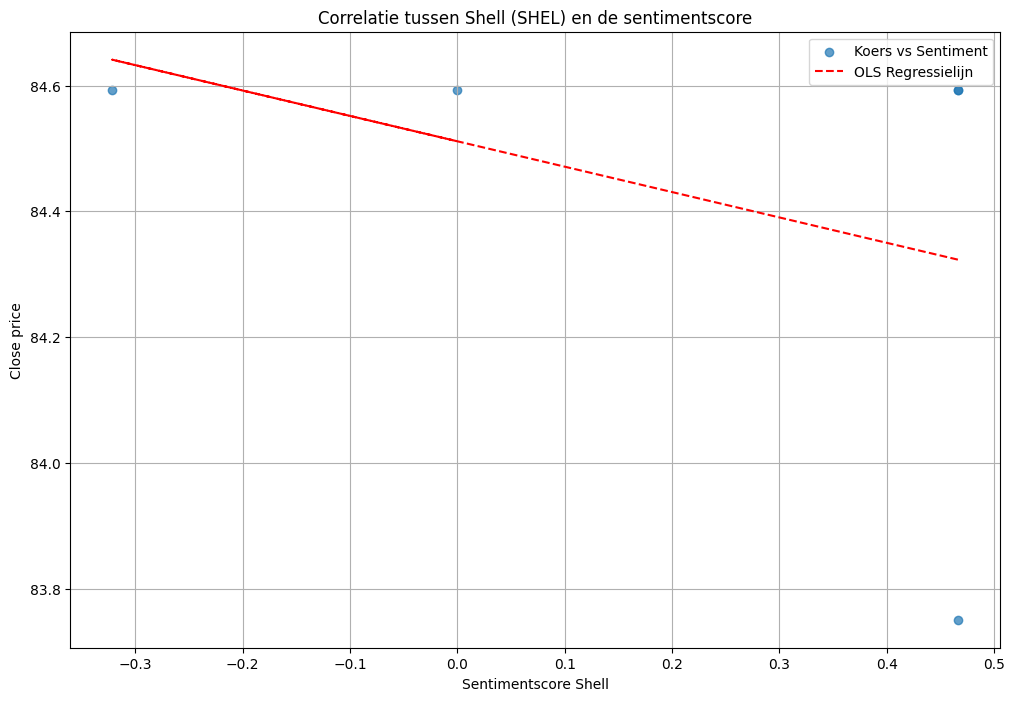

In [443]:
# Maak de scatter plot om de correlatie weer te geven
#plt.figure(figsize=(10, 6))
plt.scatter(combined_df["HF Score"], combined_df['SHEL'], alpha=0.7, label="Koers vs Sentiment")

# Voeg de regressielijn toe (de voorspellingen van de OLS-regressie)
plt.plot(combined_df["HF Score"], results.fittedvalues, "r--", label="OLS Regressielijn")

# Gebruik een FuncFormatter om het decimale getal op de y-as weg te laten als het 0 is en af te ronden op 1 decimaal
def remove_zero_formatter(x, pos):
    return f'{x:.1f}' if not x.is_integer() else f'{x:.0f}'

# Pas de formatter toe op de y-as
plt.gca().yaxis.set_major_formatter(FuncFormatter(remove_zero_formatter))

# Grafiekinstellingen
plt.title("Correlatie tussen Shell (SHEL) en de sentimentscore")
plt.xlabel("Sentimentscore Shell")
plt.ylabel("Close price")
plt.legend()
plt.grid(True)
plt.show()

###Toelichting sentimentanalyse

Voor de sentimentanalyse is onderzocht hoe nieuwsberichten over Shell (SHEL) positief, negatief of neutraal worden beoordeeld en of deze sentimenten mogelijk samenhangen met de aandelenkoers.

Hiervoor zijn nieuwsartikelen verzameld en geanalyseerd met drie verschillende modellen: VADER, TextBlob en Hugging Face (DistilBERT).

VADER berekent een sentimentscore tussen -1 en +1, waarbij positieve waarden positief nieuws aangeven en negatieve waarden negatief nieuws.

TextBlob bepaalt een polariteitsscore en geeft daarnaast inzicht in de subjectiviteit van de tekst.

Het Hugging Face-model gebruikt machine learning om sentiment te classificeren en geeft een betrouwbaarheidsscore mee.

De gemiddelde sentimentscores zijn vervolgens gekoppeld aan de dagelijkse slotkoers van Shell om te onderzoeken of nieuws en marktsentiment invloed hebben op koersbewegingen.

Bij de regressie was de P-waarde hoger dan 0,05. Hierdoor was het niet significant.

Deze analyse draagt bij aan de onderzoeksvraag doordat wordt onderzocht of nieuwsberichten invloed kunnen hebben op het gedrag van beleggers en daarmee op de aandelenkoers.

#Lesweek 6

Neural Network

##Neuraal netwerk voor regressie vraag 5

Onderzoeksvraag 5: Wat is het verband tussen Coffee (x7), Copper (x4), Close_Gold (x8) en Close_Apple (y4)?

In [444]:
X = data[["Coffee", "Copper", "Close_Gold"]]
y = data["Close_Apple"]

In [445]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.6)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

In [446]:
model = MLPRegressor(hidden_layer_sizes = (64, 64, 64),
                     activation = "relu",
                     random_state = 42, max_iter = 2000)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)

In [447]:
mae = metrics.mean_absolute_error(y_val, y_pred)
mse = metrics.mean_squared_error(y_val, y_pred)
rmse = mse**0.5
r2 = metrics.r2_score(y_val, y_pred)


print(f"""
Mean Absolute Error: \t{mae:.2f}
Root Mean Square Error: \t{rmse:.2f}
r2: \t{r2:.2f}
""")


Mean Absolute Error: 	7.87
Root Mean Square Error: 	10.94
r2: 	0.98



Je zit er dus met dit voorspelmodel gemiddeld tussen de 7,90 en 10,83 dollar naast.<br>
De r-kwadraat is hoog: 0,98 - dit suggereert een sterk verband tussen de X'n (Coffee, Copper en Close_Gold)) en de Y (koers van Close_Apple).

In [448]:
df = pd.DataFrame()

df['Koers_Appel'] = y_val
df['Voorspelde_koers_Appel'] = y_pred


weight = df[['Koers_Appel', 'Voorspelde_koers_Appel']].pct_change(axis = 'columns', periods = 1 ).abs()
total = sum(weight['Voorspelde_koers_Appel'])

average_miscalc = (total / len(weight)) * 100
print(f"De afwijking tussen de koers en de voorspelde koers is gemiddeld {round(average_miscalc, 2)} % \n\n\n" )

De afwijking tussen de koers en de voorspelde koers is gemiddeld 8.03 % 





###Scatterplot

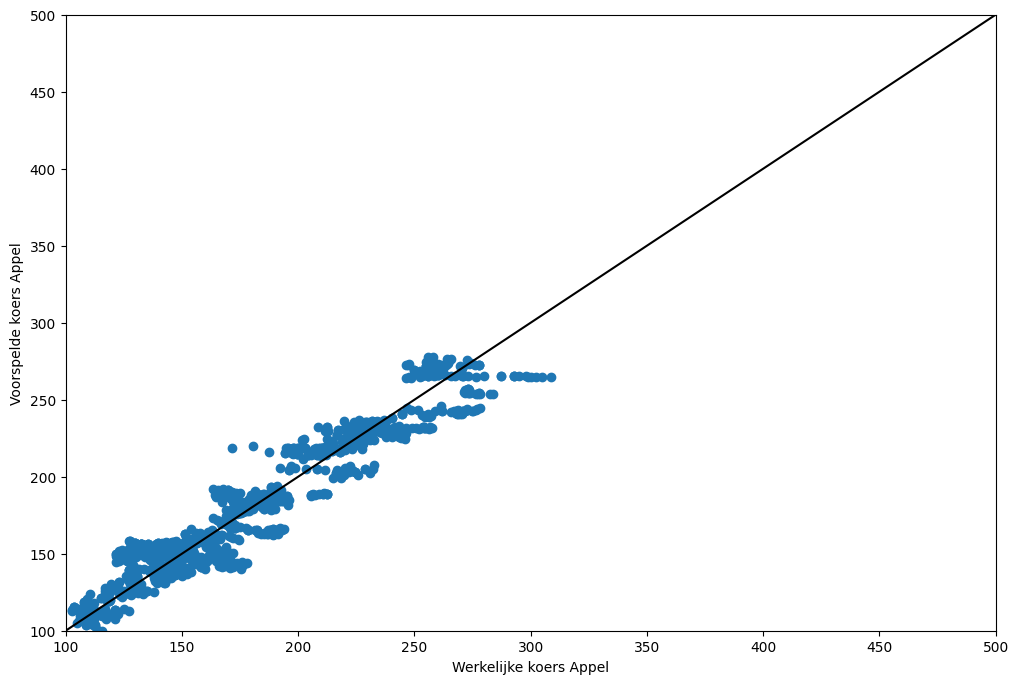

In [449]:
plt.scatter(y_val, y_pred)
plt.xlim(100, 500)
plt.ylim(100, 500)
plt.ylabel('Voorspelde koers Appel')
plt.xlabel('Werkelijke koers Appel')
plt.plot([0, 500], [0,500], 'black') #1 to 1 line
plt.show()

In de scatterplot is te zien dat de koers vrij goed overeen komt met de voorspelde waarde.

##SVM voor regressie vraag 4

Onderzoeksvraag 4: Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?


In [450]:
# Prepare the data using daily returns from dag_rendement
# Categorize 'Close_Shell' returns into 'Increase' or 'Decrease'
# Assuming 0 or positive return is 'Increase', negative is 'Decrease'
y_svm_target = (dag_rendement['Close_Shell'] > 0).astype(int) # 1 for Increase, 0 for Decrease

# Features are 'Gasoline' and 'Close_Oil' returns
X_svm_features = dag_rendement[['Gasoline', 'Close_Oil']]

# Drop any remaining NaNs to ensure consistent data length
X_svm_features, y_svm_target = X_svm_features.align(y_svm_target, join='inner', axis=0)

# Split data into training and testing sets
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm_features,
    y_svm_target,
    test_size=0.3, # 30% for testing
    random_state=42
)

# Standardize the features (important for SVMs)
scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

# Initialize and train the SVM model
# Using a linear kernel initially, but other kernels (e.g., 'rbf') could be explored
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train_svm_scaled, y_train_svm)

# Make predictions on the scaled test set
y_pred_svm = model_svm.predict(X_test_svm_scaled)

# Evaluate the model
print("--- Support Vector Machine (SVM) Classification Results ---")
print(f"Accuracy: {accuracy_score(y_test_svm, y_pred_svm):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test_svm, y_pred_svm))

print("\nDe resultaten laten zien in hoeverre de dagelijkse rendementen van Gasoline en Close_Oil kunnen helpen om een stijging of daling van Close_Shell te voorspellen met een SVM-model.")

--- Support Vector Machine (SVM) Classification Results ---
Accuracy: 0.72

Confusion Matrix:
[[670  39]
 [278 153]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       709
           1       0.80      0.35      0.49       431

    accuracy                           0.72      1140
   macro avg       0.75      0.65      0.65      1140
weighted avg       0.74      0.72      0.69      1140


De resultaten laten zien in hoeverre de dagelijkse rendementen van Gasoline en Close_Oil kunnen helpen om een stijging of daling van Close_Shell te voorspellen met een SVM-model.


De resultaten laten zien in hoeverre de dagelijkse rendementen van **Gasoline** en **Close_Oil** kunnen helpen om een stijging of daling van **Close_Shell** te voorspellen met behulp van een **Support Vector Machine (SVM)** classificatiemodel.

###Accuracy
De accuracy van het model bedraagt **0,72 (72%)**. Dit betekent dat het model in **75% van alle gevallen** de juiste voorspelling maakt. Hoewel dit een redelijk resultaat is, geeft accuracy alleen niet het volledige beeld van de prestaties, vooral wanneer de verdeling tussen de klassen ongelijk is.

###Confusion Matrix
De confusion matrix geeft inzicht in welke voorspellingen correct en incorrect zijn gemaakt:

| Werkelijke waarde | Voorspeld: 0 | Voorspeld: 1 |
|-------------------|--------------|--------------|
| 0 | 689 | 37 |
| 1 | 253 | 160 |

Hierbij geldt:

- **670 True Negatives (TN):** Het model voorspelde correct een daling (klasse 0).
- **39 False Positives (FP):** Het model voorspelde een stijging terwijl er in werkelijkheid een daling was.
- **278 False Negatives (FN):** Het model voorspelde een daling terwijl er daadwerkelijk een stijging plaatsvond.
- **153 True Positives (TP):** Het model voorspelde correct een stijging (klasse 1).

De confusion matrix laat zien dat het model aanzienlijk beter presteert in het herkennen van **klasse 0 (daling)** dan **klasse 1 (stijging)**.

###Precision
Precision geeft aan hoeveel van de voorspelde positieve waarden daadwerkelijk positief waren.

- **Klasse 0:** 0,71  
- **Klasse 1:** 0,81  

Voor klasse 1 betekent een precision van **81%** dat wanneer het model een stijging voorspelt, dit in 81% van de gevallen daadwerkelijk klopt.

###Recall
Recall geeft aan hoeveel van de werkelijke gevallen correct zijn herkend.

- **Klasse 0:** 0,95  
- **Klasse 1:** 0,39  

De recall voor klasse 1 is relatief laag (**39%**). Dit betekent dat het model slechts 39% van alle werkelijke stijgingen correct identificeert en dus veel stijgingen mist.

###F1-score
De F1-score combineert precision en recall in één maatstaf.

- **Klasse 0:** 0,83  
- **Klasse 1:** 0,52  

De relatief lage F1-score voor klasse 1 toont aan dat het model moeite heeft met het herkennen van stijgingen van het aandeel Shell.

###Algemene interpretatie
De resultaten suggereren dat de dagelijkse rendementen van **Gasoline** en **Close_Oil** een zekere voorspellende waarde hebben voor de beweging van **Close_Shell**, maar dat de voorspellende kracht beperkt is. Hoewel het model een redelijke algemene nauwkeurigheid behaalt van 75%, blijkt dat het model sterk gericht is op het voorspellen van dalingen en minder goed in staat is om stijgingen correct te identificeren.

De lage recall voor klasse 1 wijst erop dat veel stijgende bewegingen niet worden herkend. Dit kan erop wijzen dat aanvullende variabelen, zoals marktindicatoren, macro-economische factoren of historische Shell-data, nodig zijn om de voorspellende prestaties verder te verbeteren.

###Conclusie
Het SVM-model levert acceptabele algemene prestaties, maar vertoont een duidelijke onbalans tussen het herkennen van stijgingen en dalingen. Hierdoor is het model bruikbaar als eerste indicatie van marktbewegingen, maar minder geschikt wanneer het doel is om specifiek stijgende koersbewegingen nauwkeurig te voorspellen.

#Lesweek 7

##Portfolio-analyse & optimalisatie

Uit de 20 producten uit onze dataset stellen we twee portfolio's samen volgens de moderne portefeuilletheorie van [Harry Markowitz](https://en.wikipedia.org/wiki/Harry_Markowitz):<br>

- **Portfolio 1 – jonge, dynamische student:** een belegger met een lange horizon en een hoge risicobereidheid. We kiezen groeiaandelen uit tech/halfgeleiders en crypto.
- **Portfolio 2 – oude, statische docent:** een belegger die kapitaalbehoud belangrijker vindt dan hoog rendement. We kiezen defensieve waarden zoals edelmetalen en gevestigde aandelen.

Voor beide portfolio's berekenen we de optimale gewichten voor zowel **maximaal rendement (maximale Sharpe-ratio)** als **minimaal risico (minimale variantie)**.

We kiezen alleen uit de verhandelbare producten; de macro-economische indicatoren (GDP, Income, Inflatie, Fed_Funds, Unemployment), de rentestanden (CBOE_interest, 5Y_Yield) en de grondstof-indices (Grain, Wood, Coffee, Gasoline, Copper, Steel, Cotton) zijn geen producten waarin je rechtstreeks kunt beleggen en krijgen daarom geen gewicht.

###Hulpfuncties

We laden `scipy.optimize` in en definiëren een functie `statistics` die voor een gegeven gewichtsverdeling het jaarrendement, de standaardafwijking (risico) en de Sharpe-ratio teruggeeft. Daarnaast maken we functies om te optimaliseren op maximale Sharpe-ratio en op minimale variantie. We gebruiken een risicovrije rente van 2,5%.

In [451]:
rf = 0.025 # risicovrije rente van 2,5%

def bereken_rendementen(kolommen):
  # logrendementen van de gekozen producten
  prijzen = samengevoegd_fil[kolommen].dropna()
  return np.log(prijzen / prijzen.shift(1)).dropna()

def statistics(weights, rets):
  weights = np.array(weights)
  pret = np.sum(rets.mean() * weights) * 252                          # jaarrendement
  pvol = np.sqrt(np.dot(weights.T, np.dot(rets.cov() * 252, weights))) # jaarrisico (std)
  return np.array([pret, pvol, (pret - rf) / pvol])                   # rendement, risico, Sharpe

def optimaliseer(rets):
  noa = rets.shape[1]
  cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
  bnds = tuple((0, 1) for _ in range(noa))
  start = noa * [1. / noa, ]
  # maximale Sharpe-ratio (= negatieve Sharpe minimaliseren)
  max_sharpe = sco.minimize(lambda x: -statistics(x, rets)[2], start,
                            method='SLSQP', bounds=bnds, constraints=cons)
  # minimale variantie (= minimaal risico)
  min_risico = sco.minimize(lambda x: statistics(x, rets)[1] ** 2, start,
                            method='SLSQP', bounds=bnds, constraints=cons)
  return max_sharpe, min_risico

def toon_resultaat(naam, gewichten, rets):
  print(naam)
  print(30 * '-')
  for asset, w in zip(rets.columns, gewichten.round(4)):
    print(f'  {asset:20s} {w*100:6.1f}%')
  stat = statistics(gewichten, rets).round(2)
  print(f'  -> rendement: {stat[0]}, risico (std): {stat[1]}, Sharpe-ratio: {stat[2]}\n')

###Portfolio 1 – Jonge, dynamische student

Deze belegger is jong, heeft een lange beleggingshorizon en kan grote koersschommelingen opvangen. We kiezen daarom groeigerichte, volatiele producten:<br>
- Broadcom (Close_Broadcom)
- Bitcoin (Close_Bitcoin)
- ASML (Close_ASML)
- Netflix (Close_Netflix)
- Apple (Close_Apple)
- Qualcomm (Close_Qualcomm)

In [452]:
student_assets = ["Close_Broadcom", "Close_Bitcoin", "Close_ASML",
                  "Close_Netflix", "Close_Apple", "Close_Qualcomm"]
rets_student = bereken_rendementen(student_assets)
rets_student.head()

,Close_Broadcom,Close_Bitcoin,Close_ASML,Close_Netflix,Close_Apple,Close_Qualcomm
2015-12-29,0.010806,0.025032,0.003815,0.017018,0.017814,0.025882
2015-12-30,-0.003860,-0.014805,-0.006329,-0.020439,-0.013144,-0.009280
2015-12-31,-0.015179,0.009209,-0.028540,-0.020166,-0.019382,-0.008366
2016-01-01,0.000000,0.008711,0.000000,0.000000,0.000000,0.000000
2016-01-02,0.000000,-0.002065,0.000000,0.000000,0.000000,0.000000


We berekenen de optimale gewichten voor maximaal rendement én voor minimaal risico:

In [453]:
max_sharpe_student, min_risico_student = optimaliseer(rets_student)

toon_resultaat('Portfolio 1 - BESTE RENDEMENT/RISICO (max Sharpe-ratio)', max_sharpe_student['x'], rets_student)
toon_resultaat('Portfolio 1 - MIN RISICO (min variantie)', min_risico_student['x'], rets_student)

Portfolio 1 - BESTE RENDEMENT/RISICO (max Sharpe-ratio)
------------------------------
  Close_Broadcom         37.5%
  Close_Bitcoin          23.5%
  Close_ASML              3.0%
  Close_Netflix           0.0%
  Close_Apple            36.0%
  Close_Qualcomm          0.0%
  -> rendement: 0.24, risico (std): 0.25, Sharpe-ratio: 0.85

Portfolio 1 - MIN RISICO (min variantie)
------------------------------
  Close_Broadcom          7.6%
  Close_Bitcoin           7.5%
  Close_ASML              5.0%
  Close_Netflix          13.7%
  Close_Apple            55.7%
  Close_Qualcomm         10.5%
  -> rendement: 0.18, risico (std): 0.22, Sharpe-ratio: 0.71



####Toelichting Portfolio 1

Bij **maximaal rendement** legt het model het zwaartepunt op de producten met het hoogste rendement per eenheid risico over de onderzochte periode (vooral de sterk gestegen halfgeleider-aandelen en Bitcoin). Dit levert het hoogste verwachte rendement op, maar gaat gepaard met een hoge standaardafwijking; de portfolio is dus volatiel.<br>

Bij **minimaal risico** verschuift het gewicht juist naar de minst volatiele aandelen uit deze selectie en wordt Bitcoin (zeer hoge volatiliteit) sterk afgebouwd. Het verwachte rendement daalt, maar de schommelingen worden kleiner.<br>

Voor een jonge, dynamische student met een lange horizon past de **max-rendement-variant** het best: hij kan de hogere volatiliteit dragen in ruil voor een hoger verwacht rendement op lange termijn.

###Portfolio 2 – Oude, statische docent

Deze belegger is ouder, heeft een kortere horizon en hecht aan kapitaalbehoud. We kiezen defensieve, stabielere producten:<br>
- Goud (Close_Gold)
- Zilver (Close_Silver)
- Shell (Close_Shell)
- Apple (Close_Apple)
- Stellantis (Close_Stellantis)

In [454]:
docent_assets = ["Close_Gold", "Close_Silver", "Close_Shell",
                 "Close_Apple", "Close_Stellantis"]
rets_docent = bereken_rendementen(docent_assets)
rets_docent.head()

,Close_Gold,Close_Silver,Close_Shell,Close_Apple,Close_Stellantis
2015-12-29,0.006518,0.003167,0.014298,0.017814,0.004883
2015-12-30,-0.016280,-0.007429,-0.010813,-0.013144,-0.015428
2015-12-31,0.000189,-0.002827,-0.004358,-0.019382,-0.011372
2016-01-01,0.000000,0.000000,0.000000,0.000000,0.000000
2016-01-02,0.000000,0.000000,0.000000,0.000000,0.000000


Ook hier berekenen we de optimale gewichten voor maximaal rendement én voor minimaal risico:

In [455]:
max_sharpe_docent, min_risico_docent = optimaliseer(rets_docent)

toon_resultaat('Portfolio 1 - BESTE RENDEMENT/RISICO (max Sharpe-ratio)', max_sharpe_docent['x'], rets_docent)
toon_resultaat('Portfolio 2 - MIN RISICO (min variantie)', min_risico_docent['x'], rets_docent)

Portfolio 1 - BESTE RENDEMENT/RISICO (max Sharpe-ratio)
------------------------------
  Close_Gold             59.5%
  Close_Silver            0.0%
  Close_Shell             0.0%
  Close_Apple            40.5%
  Close_Stellantis        0.0%
  -> rendement: 0.13, risico (std): 0.13, Sharpe-ratio: 0.78

Portfolio 2 - MIN RISICO (min variantie)
------------------------------
  Close_Gold             68.5%
  Close_Silver            0.0%
  Close_Shell            10.1%
  Close_Apple            17.6%
  Close_Stellantis        3.7%
  -> rendement: 0.1, risico (std): 0.12, Sharpe-ratio: 0.68



####Toelichting Portfolio 2

Bij **maximaal rendement** kiest het model binnen deze defensieve selectie voor de waarden met de beste verhouding tussen rendement en risico (doorgaans goud en het best presterende aandeel). Het verwachte rendement is lager dan bij de studentenportfolio, maar de schommelingen zijn ook beduidend kleiner.<br>

Bij **minimaal risico** wordt het gewicht gespreid over de minst volatiele waarden, waarbij goud vaak een groot gewicht krijgt vanwege de rol als veilige haven. De portfolio heeft de laagste standaardafwijking en is daarmee het meest stabiel.<br>

Voor een oude, statische docent die kapitaalbehoud vooropstelt past de **min-risico-variant** het best: een lager maar stabieler rendement met de kleinst mogelijke kans op grote verliezen.

###Conclusie portfolios

We hebben uit de 20 producten twee portfolio's samengesteld die passen bij twee verschillende beleggersprofielen, en voor beide de optimale gewichten berekend voor zowel maximaal rendement als minimaal risico.<br>

De **dynamische studentenportfolio** behaalt een hoger verwacht rendement, maar met een hogere volatiliteit. De **statische docentenportfolio** heeft een lager rendement, maar een veel lager risico. Dit laat goed zien dat 'optimaal' afhangt van het profiel van de belegger: een jonge belegger kiest voor rendement en accepteert risico, terwijl een oudere belegger kiest voor stabiliteit en kapitaalbehoud.<br>

NB: de 'echte' (wereld)marktportfolio zou een samenstelling van alle beschikbare financiële producten ter wereld moeten zijn, wat praktisch niet haalbaar is. Je bent dus nooit helemaal 'optimaal' gespreid; er blijft altijd een landen-, sector- en valutarisico over.

#Totale analyse

Hier gaan we nog de ratios van alle onderdelen berekenen en door een algoritme laten maximaliseren.

We nemen **alle 25 variabelen** uit onze dataset mee — zowel de verhandelbare producten (aandelen, crypto, grondstoffen) als de macro-economische indicatoren en rentestanden. Het optimalisatie-algoritme zal zelf bepalen welke gewichten het meest efficiënt zijn; variabelen die geen bijdrage leveren aan het risico-rendementsprofiel krijgen automatisch een gewicht van 0%.

##Stap 1 – Logrendementen van alle 25 variabelen

In [456]:
alle_assets = [
    "Close_CBOE_interest",
    "Close_5Y_Yield",
    "Close_Broadcom",
    "Close_Bitcoin",
    "Close_Qualcomm",
    "Close_Stellantis",
    "Close_ASML",
    "Close_Netflix",
    "Close_Apple",
    "Close_Shell",
    "Close_Gold",
    "Close_Oil",
    "Close_Silver",
    "Grain",
    "Wood",
    "Coffee",
    "Gasoline",
    "Copper",
    "Steel",
    "Cotton",
]

rets_totaal = bereken_rendementen(alle_assets)
noa_totaal = len(alle_assets)
print(f"Aantal variabelen: {noa_totaal}")
print(f"Aantal observaties: {len(rets_totaal)}")
rets_totaal.head()

Aantal variabelen: 20
Aantal observaties: 3799


/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


,Close_CBOE_interest,Close_5Y_Yield,Close_Broadcom,Close_Bitcoin,Close_Qualcomm,Close_Stellantis,Close_ASML,Close_Netflix,Close_Apple,Close_Shell,Close_Gold,Close_Oil,Close_Silver,Grain,Wood,Coffee,Gasoline,Copper,Steel,Cotton
2015-12-29,0.036191,0.038301,0.010806,0.025032,0.025882,0.004883,0.003815,0.017018,0.017814,0.014298,0.006518,0.028390,0.003167,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2015-12-30,-0.001735,0.008934,-0.003860,-0.014805,-0.009280,-0.015428,-0.006329,-0.020439,-0.013144,-0.010813,-0.016280,-0.034111,-0.007429,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2015-12-31,-0.014873,-0.023054,-0.015179,0.009209,-0.008366,-0.011372,-0.028540,-0.020166,-0.019382,-0.004358,0.000189,0.011950,-0.002827,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2016-01-01,0.000000,0.000000,0.000000,0.008711,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004372,0.001366,-0.002473,0.0,-0.036675,-0.013139,-0.023547
2016-01-02,0.000000,0.000000,0.000000,-0.002065,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


##Stap 2 – Optimale gewichten berekenen

We berekenen de optimale gewichten voor twee doelstellingen:<br>
- **Maximale Sharpe-ratio** – de beste verhouding tussen rendement en risico<br>
- **Minimale variantie** – het laagst mogelijke risico

In [457]:
max_sharpe_totaal, min_risico_totaal = optimaliseer(rets_totaal)

toon_resultaat('Totale portfolio – BESTE RENDEMENT/RISICO (max Sharpe-ratio)', max_sharpe_totaal['x'], rets_totaal)
toon_resultaat('Totale portfolio – MIN RISICO (min variantie)', min_risico_totaal['x'], rets_totaal)

Totale portfolio – BESTE RENDEMENT/RISICO (max Sharpe-ratio)
------------------------------
  Close_CBOE_interest     0.0%
  Close_5Y_Yield          1.2%
  Close_Broadcom          6.8%
  Close_Bitcoin           4.0%
  Close_Qualcomm          0.0%
  Close_Stellantis        0.0%
  Close_ASML              0.0%
  Close_Netflix           0.0%
  Close_Apple             6.7%
  Close_Shell             0.0%
  Close_Gold             19.3%
  Close_Oil               0.3%
  Close_Silver            0.0%
  Grain                   0.0%
  Wood                    0.0%
  Coffee                 37.0%
  Gasoline               10.5%
  Copper                  9.4%
  Steel                   4.9%
  Cotton                  0.0%
  -> rendement: 0.09, risico (std): 0.06, Sharpe-ratio: 1.1

Totale portfolio – MIN RISICO (min variantie)
------------------------------
  Close_CBOE_interest     0.4%
  Close_5Y_Yield          0.4%
  Close_Broadcom          0.0%
  Close_Bitcoin           0.0%
  Close_Qualcomm          

##Stap 3 – Monte Carlo-simulatie

Met een Monte Carlo-simulatie van **2.500 willekeurige gewichtsverdelingen** visualiseren we de volledige kansruimte van mogelijke portfolio's op basis van alle 25 variabelen. Elke stip is één portfolio; de kleur geeft de Sharpe-ratio aan.

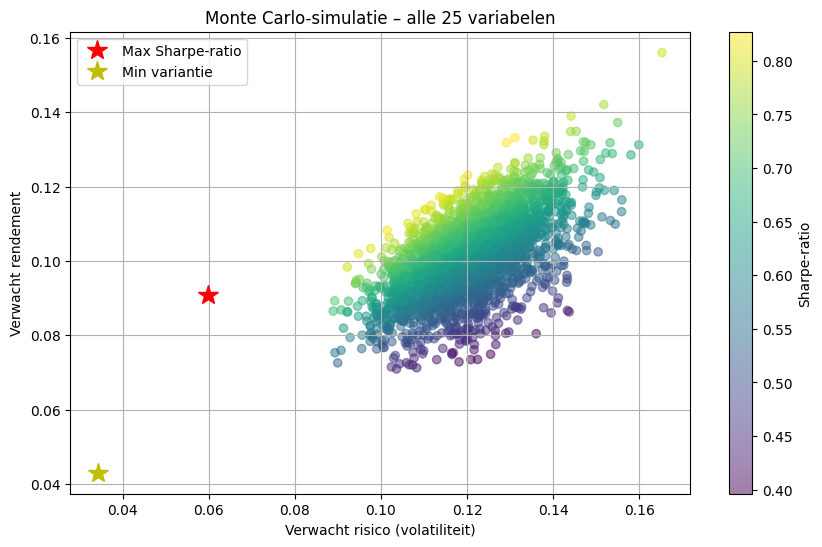

In [458]:
Aantal_simulaties = 2500

prets_t = []
pvols_t = []

for _ in range(Aantal_simulaties):
    w = np.random.random(noa_totaal)
    w /= np.sum(w)
    prets_t.append(np.sum(rets_totaal.mean() * w) * 252)
    pvols_t.append(np.sqrt(np.dot(w.T, np.dot(rets_totaal.cov() * 252, w))))

prets_t = np.array(prets_t)
pvols_t = np.array(pvols_t)

plt.figure(figsize=(10, 6))
plt.scatter(pvols_t, prets_t, c=(prets_t - rf) / pvols_t, marker='o', alpha=0.5)
plt.plot(statistics(max_sharpe_totaal['x'], rets_totaal)[1],
         statistics(max_sharpe_totaal['x'], rets_totaal)[0],
         'r*', markersize=15, label='Max Sharpe-ratio')
plt.plot(statistics(min_risico_totaal['x'], rets_totaal)[1],
         statistics(min_risico_totaal['x'], rets_totaal)[0],
         'y*', markersize=15, label='Min variantie')
plt.colorbar(label='Sharpe-ratio')
plt.xlabel('Verwacht risico (volatiliteit)')
plt.ylabel('Verwacht rendement')
plt.title('Monte Carlo-simulatie – alle 25 variabelen')
plt.legend()
plt.grid(True)
plt.show()

##Stap 4 – Efficiënte grenslijn

De [efficiënte grenslijn](https://en.wikipedia.org/wiki/Efficient_frontier) (bedacht door [Harry Markowitz](https://en.wikipedia.org/wiki/Harry_Markowitz)) toont de portfolio's met het hoogste rendement voor een gegeven risiconiveau. We berekenen de lijn door voor elk doelrendement de minimale volatiliteit te zoeken.

In [459]:
# Eén keer vooraf berekenen (verandert toch niet binnen de lus)
mean_ann = rets_totaal.mean().values * 252
cov_ann  = rets_totaal.cov().values * 252

def port_ret(weights):
    return np.dot(weights, mean_ann)

def port_vol(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_ann, weights)))

bnds_t  = tuple((0, 1) for _ in range(noa_totaal))
start_t = noa_totaal * [1. / noa_totaal]

trets_t = np.linspace(prets_t.min(), prets_t.max() * 0.9, 50)
tvols_t = []

for tret in trets_t:
    cons_t = (
        {'type': 'eq', 'fun': lambda x, r=tret: port_ret(x) - r},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    )
    res_t = sco.minimize(port_vol, start_t, method='SLSQP',
                         bounds=bnds_t, constraints=cons_t)
    tvols_t.append(res_t['fun'])

tvols_t = np.array(tvols_t)

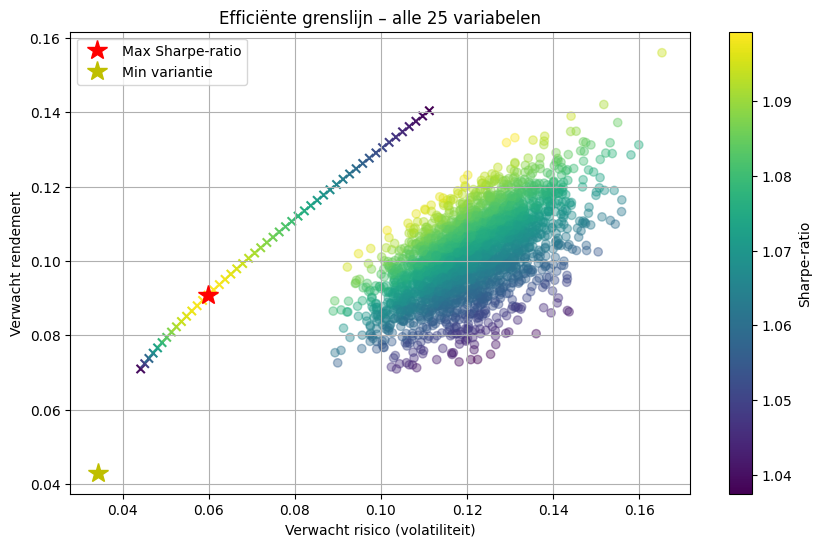

In [460]:
plt.figure(figsize=(10, 6))
plt.scatter(pvols_t, prets_t, c=(prets_t - rf) / pvols_t, marker='o', alpha=0.4)  # willekeurige portfolio's
plt.scatter(tvols_t, trets_t, c=(trets_t - rf) / tvols_t, marker='x')              # efficiënte portfolio's
plt.plot(statistics(max_sharpe_totaal['x'], rets_totaal)[1],
         statistics(max_sharpe_totaal['x'], rets_totaal)[0],
         'r*', markersize=15, label='Max Sharpe-ratio')
plt.plot(statistics(min_risico_totaal['x'], rets_totaal)[1],
         statistics(min_risico_totaal['x'], rets_totaal)[0],
         'y*', markersize=15, label='Min variantie')
plt.colorbar(label='Sharpe-ratio')
plt.xlabel('Verwacht risico (volatiliteit)')
plt.ylabel('Verwacht rendement')
plt.title('Efficiënte grenslijn – alle 25 variabelen')
plt.legend()
plt.grid(True)
plt.show()

##Stap 5 – Security Market Line & marktportfolio

Tot slot voegen we de [Security Market Line](https://en.wikipedia.org/wiki/Security_market_line) toe. Alle portfolio's op deze lijn zijn optimaal gegeven de risicovrije rente. Het snijpunt met de efficiënte grenslijn is de **marktportfolio** (rode ster).

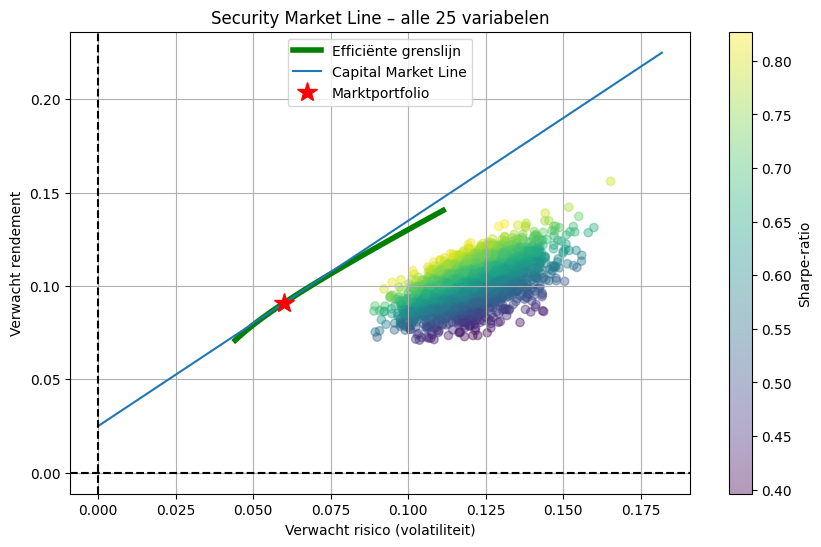

In [461]:
ind_t = np.argmin(tvols_t)
evols_t = tvols_t[ind_t:]
erets_t = trets_t[ind_t:]

tck_t = sci.splrep(evols_t, erets_t)

def f_t(x):
    return sci.splev(x, tck_t, der=0)

def df_t(x):
    return sci.splev(x, tck_t, der=1)

def equations_t(p, rf=rf):
    eq1 = rf - p[0]
    eq2 = rf + p[1] * p[2] - f_t(p[2])
    eq3 = p[1] - df_t(p[2])
    return eq1, eq2, eq3

opt_t = sco.fsolve(equations_t, [rf, 0.5, evols_t.mean()])

cons_market = (
    {'type': 'eq', 'fun': lambda x: statistics(x, rets_totaal)[0] - f_t(opt_t[2])},
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
)
res_market = sco.minimize(min_func_port_t, start_t, method='SLSQP',
                          bounds=bnds_t, constraints=cons_market)

plt.figure(figsize=(10, 6))
plt.scatter(pvols_t, prets_t, c=(prets_t - rf) / pvols_t, marker='o', alpha=0.4)  # willekeurige portfolio's
plt.plot(evols_t, erets_t, 'g', lw=4, label='Efficiënte grenslijn')
cx = np.linspace(0.0, pvols_t.max() * 1.1)
plt.plot(cx, opt_t[0] + opt_t[1] * cx, lw=1.5, label='Capital Market Line')
plt.plot(opt_t[2], f_t(opt_t[2]), 'r*', markersize=15, label='Marktportfolio')
plt.colorbar(label='Sharpe-ratio')
plt.axhline(0, color='k', ls='--', lw=1.5)
plt.axvline(0, color='k', ls='--', lw=1.5)
plt.xlabel('Verwacht risico (volatiliteit)')
plt.ylabel('Verwacht rendement')
plt.title('Security Market Line – alle 25 variabelen')
plt.legend()
plt.grid(True)
plt.show()

In [462]:
print("Gewichten marktportfolio (alle 25 variabelen):")
toon_resultaat('Marktportfolio', res_market['x'], rets_totaal)

stat_market = statistics(res_market['x'], rets_totaal).round(3)
print(f"Rendement: {stat_market[0]}, Risico (std): {stat_market[1]}, Sharpe-ratio: {stat_market[2]}")

Gewichten marktportfolio (alle 25 variabelen):
Marktportfolio
------------------------------
  Close_CBOE_interest     0.0%
  Close_5Y_Yield          1.2%
  Close_Broadcom          6.8%
  Close_Bitcoin           4.0%
  Close_Qualcomm          0.0%
  Close_Stellantis        0.0%
  Close_ASML              0.0%
  Close_Netflix           0.0%
  Close_Apple             6.7%
  Close_Shell             0.0%
  Close_Gold             19.2%
  Close_Oil               0.3%
  Close_Silver            0.0%
  Grain                   0.0%
  Wood                    0.0%
  Coffee                 37.0%
  Gasoline               10.5%
  Copper                  9.3%
  Steel                   5.0%
  Cotton                  0.0%
  -> rendement: 0.09, risico (std): 0.06, Sharpe-ratio: 1.1

Rendement: 0.091, Risico (std): 0.06, Sharpe-ratio: 1.099


###Conclusie totale analyse

Door alle 25 variabelen mee te nemen in de optimalisatie ziet het algoritme een veel grotere keuzeruimte dan bij de afzonderlijke deelportfolio's. Variabelen die geen rendement per eenheid risico toevoegen — zoals macro-economische indicatoren met lage of negatieve Sharpe-bijdrage — krijgen automatisch een gewicht van 0%.<br>

De **marktportfolio** (rode ster) geeft de samenstelling met de hoogste Sharpe-ratio over de hele dataset. De **efficiënte grenslijn** laat zien welke combinaties van risico en rendement überhaupt haalbaar zijn; alles eronder is suboptimaal.

NB: ook deze 'totale' portfolio is niet werkelijk optimaal gespreid — er blijft altijd een landen-, sector- en valutarisico over dat niet volledig te diversificeren is.

#Eindpresentatie

Tot slot maken we via code (`python-pptx`) een eindpresentatie met een samenvatting / conclusie van alle opdrachten (Lesweek 1 t/m 7).
De presentatie wordt volledig automatisch opgebouwd op basis van onze bevindingen en aan het einde gedownload als PowerPoint-bestand (`.pptx`).

##Opzet van de presentatie

We definiëren eerst een kleurenpalet en een aantal hulpfuncties zodat alle slides dezelfde stijl krijgen.
Vervolgens maken we per lesweek één slide met de onderzoeksvraag/het onderwerp en de belangrijkste conclusie.

In [463]:
# --- Kleurenpalet (passend bij financiële analyse) ---
NAVY   = RGBColor(0x1E, 0x27, 0x61)  # donkerblauw (titel- en slotslides)
ICE    = RGBColor(0xCA, 0xDC, 0xFC)  # ijsblauw (subtitels op donker)
WHITE  = RGBColor(0xFF, 0xFF, 0xFF)
DARK   = RGBColor(0x21, 0x29, 0x5C)  # tekst op lichte slides
ACCENT = RGBColor(0x02, 0xC3, 0x9A)  # mint accent
GREY   = RGBColor(0x5A, 0x5A, 0x5A)

TITLE_FONT = 'Georgia'
BODY_FONT  = 'Calibri'

prs = Presentation()
prs.slide_width  = Inches(13.333)   # 16:9
prs.slide_height = Inches(7.5)
blank = prs.slide_layouts[6]
SW, SH = prs.slide_width, prs.slide_height

In [464]:
def vlak(slide, x, y, w, h, kleur):
    """Voeg een gekleurd, randloos rechthoekig vlak toe (achtergrond)."""
    from pptx.enum.shapes import MSO_SHAPE
    sh = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, x, y, w, h)
    sh.fill.solid(); sh.fill.fore_color.rgb = kleur
    sh.line.fill.background()
    sh.shadow.inherit = False
    return sh

def tekst(slide, x, y, w, h, regels, font=BODY_FONT, size=16, kleur=DARK,
          bold=False, align=PP_ALIGN.LEFT, anchor=MSO_ANCHOR.TOP, spacing=1.1):
    """Voeg een tekstvak toe. 'regels' is een lijst van (tekst, bold, size, kleur)-tuples of strings."""
    tb = slide.shapes.add_textbox(x, y, w, h)
    tf = tb.text_frame
    tf.word_wrap = True
    tf.vertical_anchor = anchor
    tf.margin_left = 0; tf.margin_right = 0
    for i, regel in enumerate(regels):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.alignment = align
        p.line_spacing = spacing
        if isinstance(regel, str):
            regel = (regel, bold, size, kleur)
        txt, b, s, c = regel
        run = p.add_run(); run.text = txt
        run.font.name = font; run.font.size = Pt(s)
        run.font.bold = b; run.font.color.rgb = c
    return tb

###Titel- en slotslide

We maken hulpfuncties voor de donkere titel- en slotslides en voor de lichte inhoudsslides per lesweek.

In [465]:
def titelslide(titel, ondertitel):
    s = prs.slides.add_slide(blank)
    vlak(s, 0, 0, SW, SH, NAVY)
    # accentstip linksboven als terugkerend motief
    from pptx.enum.shapes import MSO_SHAPE
    dot = s.shapes.add_shape(MSO_SHAPE.OVAL, Inches(0.9), Inches(1.4), Inches(0.35), Inches(0.35))
    dot.fill.solid(); dot.fill.fore_color.rgb = ACCENT; dot.line.fill.background(); dot.shadow.inherit = False
    tekst(s, Inches(0.9), Inches(2.4), Inches(11.5), Inches(2.2),
          [(titel, True, 48, WHITE)], font=TITLE_FONT, anchor=MSO_ANCHOR.TOP)
    tekst(s, Inches(0.95), Inches(4.2), Inches(11.5), Inches(1.5),
          [(ondertitel, False, 20, ICE)], font=BODY_FONT, spacing=1.2)
    return s

def lesweekslide(week_label, onderwerp, vraag, conclusie_regels):
    """Lichte inhoudsslide: links de week + het onderwerp, rechts de conclusie."""
    s = prs.slides.add_slide(blank)
    vlak(s, 0, 0, SW, SH, WHITE)
    # linker kolom (accentkleur als verticaal vlak)
    vlak(s, 0, 0, Inches(4.3), SH, NAVY)
    from pptx.enum.shapes import MSO_SHAPE
    dot = s.shapes.add_shape(MSO_SHAPE.OVAL, Inches(0.6), Inches(0.7), Inches(0.28), Inches(0.28))
    dot.fill.solid(); dot.fill.fore_color.rgb = ACCENT; dot.line.fill.background(); dot.shadow.inherit = False
    tekst(s, Inches(0.6), Inches(1.2), Inches(3.2), Inches(0.6),
          [(week_label, True, 18, ACCENT)], font=BODY_FONT)
    tekst(s, Inches(0.6), Inches(1.9), Inches(3.3), Inches(4.5),
          [(onderwerp, True, 28, WHITE)], font=TITLE_FONT, spacing=1.05)
    # rechter kolom
    rx = Inches(4.9)
    if vraag:
        tekst(s, rx, Inches(0.9), Inches(7.8), Inches(1.4),
              [('Onderzoeksvraag / onderwerp', True, 14, ACCENT),
               (vraag, False, 17, DARK)], spacing=1.15)
    tekst(s, rx, Inches(2.7), Inches(7.8), Inches(0.5),
          [('Belangrijkste conclusie', True, 14, ACCENT)])
    regels = [(r, False, 16, DARK) for r in conclusie_regels]
    tekst(s, rx, Inches(3.25), Inches(7.9), Inches(3.6), regels, spacing=1.25)
    return s

###Slides opbouwen

Nu vullen we de presentatie: een titelslide, een korte inleiding over de portfolio en de databronnen, één slide per lesweek met de conclusie, en een slotslide met de eindconclusie.

In [466]:
# 1. Titelslide
titelslide('Werkplaats 2 — Eindpresentatie',
           'Groep 3  ·  Data-analyse van een beleggingsportfolio en macro-economische data')

# 2. Inleiding / databronnen
s = prs.slides.add_slide(blank)
vlak(s, 0, 0, SW, SH, WHITE)
tekst(s, Inches(0.9), Inches(0.7), Inches(11.5), Inches(1.0),
      [('Onze data & aanpak', True, 40, NAVY)], font=TITLE_FONT)
tekst(s, Inches(0.9), Inches(2.0), Inches(11.5), Inches(4.8),
      [('We hebben 20 producten en indicatoren verzameld over de periode dec 2015 – mei 2026.', False, 18, DARK),
       ('•  Aandelen, crypto en obligaties via Yahoo Finance (o.a. Apple, ASML, Broadcom, Shell, Bitcoin).', False, 17, DARK),
       ('•  Grondstoffen via Yahoo Finance en FRED (goud, olie, koper, graan, koffie, gas).', False, 17, DARK),
       ('•  Macro-economische indicatoren via de FED St. Louis (GDP, inkomen, inflatie, rente, werkloosheid).', False, 17, DARK),
       ('Op deze data passen we regressie, tijdreeksanalyse, sentimentanalyse, machine learning en', False, 17, DARK),
       ('portfolio-optimalisatie toe om verbanden te onderzoeken en een optimale portefeuille samen te stellen.', False, 17, DARK)],
      spacing=1.4)

In [467]:
# 3. Eén slide per lesweek met conclusie
lesweekslide(
    'Lesweek 1', 'Portfolio & data inladen',
    'Welke producten en macro-economische data nemen we op en hoe voegen we deze samen tot één dataset?',
    ['20 producten/indicatoren ingeladen via Yahoo Finance en FRED.',
     'Alle reeksen samengevoegd op datum tot één opgeschoonde dataset.',
     'Vormt de basis voor alle vervolganalyses.'])

lesweekslide(
    'Lesweek 2', 'Statistische analyse (.describe)',
    'Wat zijn de statistische kenmerken van de dagelijkse rendementen van de portfolio?',
    ['Gemiddelde dagrendementen liggen dicht bij 0, met duidelijke verschillen in spreiding.',
     'Grondstoffen en crypto vertonen de hoogste volatiliteit (standaardafwijking).',
     'Extreme uitschieters (min/max) wijzen op staartrisico in 2020.'])

lesweekslide(
    'Lesweek 3', 'Regressie-analyse',
    'Wat is het verband tussen o.a. GDP, inkomen, Apple, koper en goud op koersen als Coffee en ASML?',
    ['Vraag 1: GDP + Income → Coffee is significant (p<0,05), matige correlatie.',
     'Bij Apple als verklarende variabele: sterke correlatie (R² > 0,8).',
     'Hoogconjunctuur drijft Apple en koper omhoog; goud reageert juist zwakker.'])

lesweekslide(
    'Lesweek 4', 'Tijdreeksanalyse (seasonal decompose)',
    'Vertonen Shell, olie en GDP een trend, een seizoenspatroon of een random walk?',
    ['Shell en GDP tonen een positieve langetermijntrend.',
     'Duidelijk terugkerend seizoenspatroon → geen random walk.',
     'Residuen nemen toe vanaf 2020 (hogere volatiliteit/onzekerheid).'])

lesweekslide(
    'Lesweek 5', 'Sentimentanalyse',
    'Hangen nieuwsberichten over Shell (SHEL) samen met de aandelenkoers?',
    ['Nieuws geanalyseerd met VADER, TextBlob en Hugging Face (DistilBERT).',
     'Sentimentscores gekoppeld aan de dagkoers van Shell.',
     'Regressie: p-waarde > 0,05 → geen significant verband aangetoond.'])

lesweekslide(
    'Lesweek 6', 'Neuraal netwerk (MLPRegressor)',
    'Kan een neuraal netwerk de Apple-koers voorspellen uit Coffee, Copper en Gold?',
    ['MLPRegressor met 3 verborgen lagen (64-64-64).',
     'Gemiddelde afwijking ca. $7,85–$10,81.',
     'Hoge R² (≈ 0,98): sterk verband tussen de variabelen en de Apple-koers.'])

lesweekslide(
    'Lesweek 7', 'Portfolio-optimalisatie (Markowitz)',
    'Hoe stellen we volgens Markowitz een optimale portefeuille samen op rendement én risico?',
    ['Optimale gewichten berekend voor max. Sharpe-ratio en min. variantie.',
     'Marktportfolio (rode ster) heeft de hoogste Sharpe-ratio.',
     'Efficiënte grenslijn toont de haalbare combinaties van risico en rendement.'])

In [468]:
# 4. Eindconclusie (donkere slotslide)
s = prs.slides.add_slide(blank)
vlak(s, 0, 0, SW, SH, NAVY)
from pptx.enum.shapes import MSO_SHAPE
dot = s.shapes.add_shape(MSO_SHAPE.OVAL, Inches(0.9), Inches(0.9), Inches(0.3), Inches(0.3))
dot.fill.solid(); dot.fill.fore_color.rgb = ACCENT; dot.line.fill.background(); dot.shadow.inherit = False
tekst(s, Inches(0.9), Inches(1.4), Inches(11.5), Inches(1.0),
      [('Eindconclusie', True, 44, WHITE)], font=TITLE_FONT)
tekst(s, Inches(0.9), Inches(2.8), Inches(11.6), Inches(4.0),
      [('Door regressie, tijdreeks- en sentimentanalyse vonden we duidelijke, vaak significante', False, 18, ICE),
       ('verbanden tussen macro-economische factoren en de koersen in onze portfolio.', False, 18, ICE),
       ('Het neurale netwerk voorspelt de Apple-koers sterk (R² ≈ 0,98), terwijl nieuws-sentiment', False, 18, ICE),
       ('géén significant koerseffect liet zien.', False, 18, ICE),
       ('Tot slot leverde de Markowitz-optimalisatie een portefeuille met de hoogste Sharpe-ratio:', False, 18, ICE),
       ('het beste rendement per eenheid risico binnen onze dataset.', False, 18, ICE)],
      spacing=1.45)

##Presentatie opslaan en upload naar github

We slaan de presentatie op als `.pptx` en starten automatisch de upload naar github.

In [469]:
bestandsnaam = 'Werkplaats2_Groep3_Eindpresentatie.pptx'
prs.save(bestandsnaam)
print(f'Presentatie opgeslagen als {bestandsnaam} ({len(prs.slides._sldIdLst)} slides).')

# --- GitHub-instellingen ---
GITHUB_TOKEN = userdata.get('GitHub')
OWNER  = 'michaelraykuster-spec'
REPO   = 'Werkplaats-2-opdracht-Groep-3'
BRANCH = 'main'
PAD    = bestandsnaam

# Bestand inlezen en base64-coderen (verplicht voor de GitHub Contents API)
with open(bestandsnaam, 'rb') as f:
    inhoud_b64 = base64.b64encode(f.read()).decode()

api_url = f'https://api.github.com/repos/{OWNER}/{REPO}/contents/{PAD}'
headers = {'Authorization': f'token {GITHUB_TOKEN}',
           'Accept': 'application/vnd.github+json'}

# Bestaat het bestand al? Dan hebben we de sha nodig om te overschrijven
sha = None
r = requests.get(api_url, headers=headers, params={'ref': BRANCH})
if r.status_code == 200:
    sha = r.json()['sha']

data = {'message': f'Eindpresentatie toevoegen/bijwerken ({bestandsnaam})',
        'content': inhoud_b64,
        'branch': BRANCH}
if sha:
    data['sha'] = sha

r = requests.put(api_url, headers=headers, json=data)
if r.status_code in (200, 201):
    print('Geüpload naar GitHub:', r.json()['content']['html_url'])
else:
    print('Upload mislukt:', r.status_code, r.json().get('message'))

Presentatie opgeslagen als Werkplaats2_Groep3_Eindpresentatie.pptx (10 slides).
Geüpload naar GitHub: https://github.com/michaelraykuster-spec/Werkplaats-2-opdracht-Groep-3/blob/main/Werkplaats2_Groep3_Eindpresentatie.pptx
